# Stage 1 confirmatory analysis: donation equivalents and LLM-expressed preferences

This notebook reads the completed Stage 1 files from Google Drive. It makes no
API calls. It addresses four questions:

1. Which endpoints produced sufficiently complete A/B data for primary inference?
2. Are direct-choice cycles robust to every possible assignment of missing responses?
3. Do donation choices decrease with donation amount, and which outcome curves show
   statistically significant decreasing trends?
4. Do finite donation-equivalent rankings predict independent direct choices within
   positive and negative valence, after a task-label permutation test?

**Important:** the quality thresholds below are post-hoc sensitivity criteria, not
preregistered exclusions. All endpoints remain in saved tables. Primary figures flag
or omit endpoints that fail the uniform reliability rule.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from __future__ import annotations

import itertools
import json
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

try:
    import statsmodels.api as sm
except ImportError:
    # Colab normally includes statsmodels. This keeps the notebook runnable in a
    # minimal runtime without asking the user to add a separate setup cell.
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])
    import statsmodels.api as sm

try:
    from IPython.display import Markdown, display
except ImportError:
    display = print
    Markdown = str

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

# Mount Drive in Colab.
try:
    from google.colab import drive

    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except ImportError:
    pass

RUN_DIR = Path(
    "/content/drive/MyDrive/apart_sprint/mint_tier4_donation_stage1_v7"
)
RESPONSES_CSV = RUN_DIR / "stage1_responses.csv"
CONFIG_JSON = RUN_DIR / "stage1_config.json"
OUTCOMES_JSON = RUN_DIR / "selected_tier4_outcomes.json"

ANALYSIS_DIR = RUN_DIR / "confirmatory_analysis_v1"
FIGURE_DIR = ANALYSIS_DIR / "figures"
TABLE_DIR = ANALYSIS_DIR / "tables"
for directory in [ANALYSIS_DIR, FIGURE_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

PRIMARY_FRAME = "wfp_emergency_food"
VALIDATION_TEMPERATURE = 1.0
ALPHA = 0.05
N_PERMUTATIONS = 20_000
PERMUTATION_BATCH_SIZE = 2_000
N_BOOTSTRAPS = 4_000
RANDOM_SEED = 20260817

# Uniform post-hoc endpoint reliability rule. It is used as a sensitivity/eligibility
# flag, while the original all-model results are still saved.
QUALITY_API_MIN = 0.95
QUALITY_CONDITIONAL_PARSE_MIN = 0.95
QUALITY_LENGTH_MAX = 0.02

print("Responses:", RESPONSES_CSV)
print("Analysis output:", ANALYSIS_DIR)



Responses: /content/drive/MyDrive/apart_sprint/mint_tier4_donation_stage1_v7/stage1_responses.csv
Analysis output: /content/drive/MyDrive/apart_sprint/mint_tier4_donation_stage1_v7/confirmatory_analysis_v1


## 1. Load and validate the completed collection



In [3]:
if not RESPONSES_CSV.exists():
    raise FileNotFoundError(f"Missing responses file: {RESPONSES_CSV}")

responses = pd.read_csv(RESPONSES_CSV, low_memory=False)
config = json.loads(CONFIG_JSON.read_text(encoding="utf-8"))
selected_outcomes = json.loads(OUTCOMES_JSON.read_text(encoding="utf-8"))

required_columns = {
    "model_label",
    "phase",
    "api_ok",
    "parse_ok",
    "provider_match",
    "parsed_choice",
    "finish_reason",
    "temperature",
    "temperature_mode",
    "left_outcome_id",
    "right_outcome_id",
    "left_valence",
    "right_valence",
    "left_side",
    "right_side",
    "outcome_id",
    "valence",
    "target_side",
    "target_kind",
    "donation_usd",
    "charity_frame",
}
missing_columns = sorted(required_columns - set(responses.columns))
if missing_columns:
    raise RuntimeError(f"Missing required columns: {missing_columns}")


def as_nullable_bool(series: pd.Series) -> pd.Series:
    if str(series.dtype) in {"bool", "boolean"}:
        return series.astype("boolean")
    mapped = (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map({"true": True, "false": False, "1": True, "0": False})
    )
    return mapped.astype("boolean")


for column in ["api_ok", "parse_ok", "provider_match", "reasoning_fallback_used"]:
    if column in responses:
        responses[column] = as_nullable_bool(responses[column])

responses["api_ok_flag"] = responses["api_ok"].fillna(False).astype(bool)
responses["parse_ok_flag"] = responses["parse_ok"].fillna(False).astype(bool)
responses["hit_max_tokens_flag"] = np.where(
    responses["api_ok_flag"],
    responses["finish_reason"].eq("length"),
    np.nan,
)
responses["temperature"] = pd.to_numeric(responses["temperature"], errors="coerce")
responses["donation_usd"] = pd.to_numeric(
    responses["donation_usd"], errors="coerce"
)
DONATION_AMOUNTS = sorted(
    pd.to_numeric(
        pd.Series(config.get("donation_amounts_usd", responses["donation_usd"].dropna().unique())),
        errors="coerce",
    ).dropna().astype(float).unique().tolist()
)
if not DONATION_AMOUNTS:
    raise RuntimeError("No donation amounts were found in the config or response data.")

print(f"Loaded {len(responses):,} response rows")
print("Models:", responses["model_label"].nunique())
print("Phases:", sorted(responses["phase"].dropna().unique()))



Loaded 475,800 response rows
Models: 10
Phases: ['direct_tier4', 'money_tier4']


## 2. Operational quality and uniform endpoint eligibility

`parse_yield` is valid A/B responses divided by all scheduled calls.
`conditional_parse_rate` is valid A/B responses divided by successful API calls.
The latter isolates response-format compliance from API availability.



In [6]:
quality = (
    responses.groupby(["model_label", "phase"], as_index=False)
    .agg(
        scheduled=("model_label", "size"),
        api_success_rate=("api_ok_flag", "mean"),
        parse_yield=("parse_ok_flag", "mean"),
        length_finish_rate=("hit_max_tokens_flag", "mean"),
        provider_match_rate=("provider_match", "mean"),
    )
)
quality["conditional_parse_rate"] = (
    quality["parse_yield"] / quality["api_success_rate"]
)


def phase_pass(row: pd.Series) -> bool:
    return bool(
        row["api_success_rate"] >= QUALITY_API_MIN
        and row["conditional_parse_rate"] >= QUALITY_CONDITIONAL_PARSE_MIN
        and row["length_finish_rate"] <= QUALITY_LENGTH_MAX
    )


quality["phase_quality_pass"] = quality.apply(phase_pass, axis=1)
model_quality = (
    quality.groupby("model_label", as_index=False)
    .agg(
        quality_eligible=("phase_quality_pass", "all"),
        minimum_api_success=("api_success_rate", "min"),
        minimum_conditional_parse=("conditional_parse_rate", "min"),
        maximum_length_finish=("length_finish_rate", "max"),
    )
)

quality_display = quality.merge(
    model_quality[["model_label", "quality_eligible"]], on="model_label"
)
display(
    quality_display.sort_values(["quality_eligible", "model_label", "phase"], ascending=[False, True, True])
    .reset_index(drop=True)
    .round(4)
)

quality.to_csv(TABLE_DIR / "operational_quality_by_phase.csv", index=False)
model_quality.to_csv(TABLE_DIR / "model_quality_eligibility.csv", index=False)

print("Quality-eligible endpoints:")
print(model_quality.loc[model_quality["quality_eligible"], "model_label"].tolist())
print("Quality-flagged endpoints:")
print(model_quality.loc[~model_quality["quality_eligible"], "model_label"].tolist())



,model_label,phase,scheduled,api_success_rate,parse_yield,length_finish_rate,provider_match_rate,conditional_parse_rate,phase_quality_pass,quality_eligible
0,gemma4_31b,direct_tier4,8700,1.0000,0.9759,0.0094,1.0,0.9759,True,True
1,gemma4_31b,money_tier4,43200,0.9999,0.9895,0.0103,1.0,0.9897,True,True
2,gpt5_4_nano,direct_tier4,8700,1.0000,1.0000,0.0000,1.0,1.0000,True,True
3,gpt5_4_nano,money_tier4,28800,0.9998,0.9998,0.0000,1.0,1.0000,True,True
4,gpt5_6_luna,direct_tier4,8700,0.9999,0.9999,0.0000,1.0,1.0000,True,True
5,gpt5_6_luna,money_tier4,28800,0.9998,0.9998,0.0000,1.0,1.0000,True,True
6,gpt5_6_terra,direct_tier4,8700,0.9998,0.9998,0.0000,1.0,1.0000,True,True
7,gpt5_6_terra,money_tier4,28800,0.9999,0.9999,0.0000,1.0,1.0000,True,True
8,llama3_3_70b,direct_tier4,8700,0.9724,0.9724,0.0000,1.0,1.0000,True,True
9,llama3_3_70b,money_tier4,43200,0.9733,0.9733,0.0000,1.0,1.0000,True,True


Quality-eligible endpoints:
['gemma4_31b', 'gpt5_4_nano', 'gpt5_6_luna', 'gpt5_6_terra', 'llama3_3_70b', 'qwen3_5_27b', 'qwen3_5_9b']
Quality-flagged endpoints:
['gemma4_26b_a4b', 'llama3_2_1b', 'llama3_2_3b']


## 3. Direct pairwise choices and missing-response-robust cycles

A pair majority is **robust to missing responses** when its current winner already
has more than half of all scheduled votes. Even assigning every API/parse failure
to the loser cannot reverse that edge.



In [7]:
direct_rows = responses.loc[responses["phase"].eq("direct_tier4")].copy()
direct_rows["valid"] = direct_rows["api_ok_flag"] & direct_rows["parse_ok_flag"]
direct_rows["prefer_left"] = np.where(
    direct_rows["valid"],
    direct_rows["parsed_choice"].eq(direct_rows["left_side"]).astype(float),
    np.nan,
)

direct_pair_keys = [
    "model_label",
    "temperature",
    "temperature_mode",
    "left_outcome_id",
    "right_outcome_id",
]

pair_summary = (
    direct_rows.groupby(direct_pair_keys, dropna=False, as_index=False)
    .agg(
        scheduled=("model_label", "size"),
        n_valid=("valid", "sum"),
        left_votes=("prefer_left", "sum"),
        left_valence=("left_valence", "first"),
        right_valence=("right_valence", "first"),
    )
)
pair_summary["right_votes"] = pair_summary["n_valid"] - pair_summary["left_votes"]
pair_summary["p_left"] = pair_summary["left_votes"] / pair_summary["n_valid"].replace(0, np.nan)
pair_summary["strict_majority"] = pair_summary["left_votes"].ne(
    pair_summary["right_votes"]
) & pair_summary["n_valid"].gt(0)
pair_summary["winner"] = np.where(
    pair_summary["left_votes"] > pair_summary["right_votes"],
    pair_summary["left_outcome_id"],
    np.where(
        pair_summary["right_votes"] > pair_summary["left_votes"],
        pair_summary["right_outcome_id"],
        None,
    ),
)
pair_summary["winner_votes"] = pair_summary[["left_votes", "right_votes"]].max(axis=1)
pair_summary["robust_majority"] = (
    pair_summary["strict_majority"]
    & (pair_summary["winner_votes"] > pair_summary["scheduled"] / 2)
)
pair_summary["decisiveness"] = (
    (pair_summary["left_votes"] - pair_summary["right_votes"]).abs()
    / pair_summary["n_valid"].replace(0, np.nan)
)


def is_cycle(triad: tuple[str, str, str], winners: dict[frozenset, str]) -> bool:
    edges = [frozenset(pair) for pair in itertools.combinations(triad, 2)]
    outdegree = {node: 0 for node in triad}
    for edge in edges:
        outdegree[winners[edge]] += 1
    return all(value == 1 for value in outdegree.values())


def triad_composition(triad: tuple[str, str, str], valence_map: dict[str, str]) -> str:
    values = {valence_map.get(node) for node in triad}
    if values == {"positive"}:
        return "positive_only"
    if values == {"negative"}:
        return "negative_only"
    return "mixed_valence"


cycle_rows = []
for setting, group in pair_summary.groupby(
    ["model_label", "temperature", "temperature_mode"], dropna=False, sort=True
):
    outcomes = sorted(
        set(group["left_outcome_id"]).union(group["right_outcome_id"])
    )
    valence_map = {}
    for row in group.itertuples(index=False):
        valence_map[row.left_outcome_id] = row.left_valence
        valence_map[row.right_outcome_id] = row.right_valence

    observed_winners = {
        frozenset((row.left_outcome_id, row.right_outcome_id)): row.winner
        for row in group.itertuples(index=False)
        if row.strict_majority
    }
    robust_winners = {
        frozenset((row.left_outcome_id, row.right_outcome_id)): row.winner
        for row in group.itertuples(index=False)
        if row.robust_majority
    }

    counters = {
        scope: {
            "observed_scorable": 0,
            "observed_cycles": 0,
            "robust_scorable": 0,
            "guaranteed_cycles": 0,
        }
        for scope in ["all", "positive_only", "negative_only", "mixed_valence"]
    }

    for triad in itertools.combinations(outcomes, 3):
        composition = triad_composition(triad, valence_map)
        scopes = ["all", composition]
        edges = [frozenset(pair) for pair in itertools.combinations(triad, 2)]

        observed_ok = all(edge in observed_winners for edge in edges)
        robust_ok = all(edge in robust_winners for edge in edges)

        for scope in scopes:
            if observed_ok:
                counters[scope]["observed_scorable"] += 1
                counters[scope]["observed_cycles"] += int(
                    is_cycle(triad, observed_winners)
                )
            if robust_ok:
                counters[scope]["robust_scorable"] += 1
                counters[scope]["guaranteed_cycles"] += int(
                    is_cycle(triad, robust_winners)
                )

    for scope, values in counters.items():
        cycle_rows.append(
            {
                "model_label": setting[0],
                "temperature": setting[1],
                "temperature_mode": setting[2],
                "triad_scope": scope,
                **values,
                "observed_cycle_rate": (
                    values["observed_cycles"] / values["observed_scorable"]
                    if values["observed_scorable"]
                    else np.nan
                ),
                "robust_subgraph_cycle_rate": (
                    values["guaranteed_cycles"] / values["robust_scorable"]
                    if values["robust_scorable"]
                    else np.nan
                ),
                # Conservative lower bound using the original observed-triad denominator.
                "guaranteed_cycle_lower_bound": (
                    values["guaranteed_cycles"] / values["observed_scorable"]
                    if values["observed_scorable"]
                    else np.nan
                ),
            }
        )

cycle_summary = pd.DataFrame(cycle_rows).merge(model_quality, on="model_label", how="left")
pair_quality_summary = (
    pair_summary.groupby(["model_label", "temperature", "temperature_mode"], as_index=False)
    .agg(
        observed_pairs=("n_valid", "size"),
        mean_valid_per_pair=("n_valid", "mean"),
        mean_decisiveness=("decisiveness", "mean"),
        robust_edge_rate=("robust_majority", "mean"),
    )
)

display(
    cycle_summary.loc[cycle_summary["triad_scope"].eq("all")]
    .merge(pair_quality_summary, on=["model_label", "temperature", "temperature_mode"])
    .sort_values("observed_cycle_rate")
    .reset_index(drop=True)
    .round(4)
)

pair_summary.to_csv(TABLE_DIR / "direct_pair_majorities.csv", index=False)
cycle_summary.to_csv(TABLE_DIR / "cycle_sensitivity_by_valence.csv", index=False)



,model_label,temperature,temperature_mode,triad_scope,observed_scorable,observed_cycles,robust_scorable,guaranteed_cycles,observed_cycle_rate,robust_subgraph_cycle_rate,guaranteed_cycle_lower_bound,quality_eligible,minimum_api_success,minimum_conditional_parse,maximum_length_finish,observed_pairs,mean_valid_per_pair,mean_decisiveness,robust_edge_rate
0,gpt5_6_terra,1.0,endpoint_default,all,3586,9,3586,9,0.0025,0.0025,0.0025,True,0.9998,1.0000,0.0000,435,19.9954,0.8908,0.9586
1,gpt5_6_luna,1.0,endpoint_default,all,3817,10,3817,10,0.0026,0.0026,0.0026,True,0.9998,1.0000,0.0000,435,19.9977,0.8657,0.9793
2,gemma4_31b,1.0,explicit,all,3690,13,3381,10,0.0035,0.0030,0.0027,True,0.9999,0.9759,0.0103,435,19.5172,0.9013,0.9356
3,llama3_3_70b,1.0,explicit,all,3605,16,3214,2,0.0044,0.0006,0.0006,True,0.9724,1.0000,0.0000,435,19.4483,0.8878,0.9241
4,qwen3_5_27b,1.0,explicit,all,3921,25,3840,18,0.0064,0.0047,0.0046,True,0.9932,1.0000,0.0000,435,19.8644,0.7812,0.9816
5,gpt5_4_nano,1.0,endpoint_default,all,3366,25,3366,25,0.0074,0.0074,0.0074,True,0.9998,1.0000,0.0000,435,20.0000,0.6708,0.9379
6,qwen3_5_9b,1.0,explicit,all,3529,31,3354,28,0.0088,0.0083,0.0079,True,0.9980,0.9964,0.0007,435,19.8897,0.6132,0.9379
7,gemma4_26b_a4b,1.0,explicit,all,3219,37,1874,0,0.0115,0.0000,0.0000,False,0.8205,0.9374,0.0027,435,15.3816,0.8229,0.7655
8,llama3_2_3b,1.0,explicit,all,3422,53,1248,0,0.0155,0.0000,0.0000,False,0.9633,0.7697,0.0425,435,14.8299,0.6245,0.6276
9,llama3_2_1b,1.0,explicit,all,1745,403,0,0,0.2309,NaN,0.0000,False,0.9999,0.1275,0.0000,435,3.4713,0.4943,0.0000


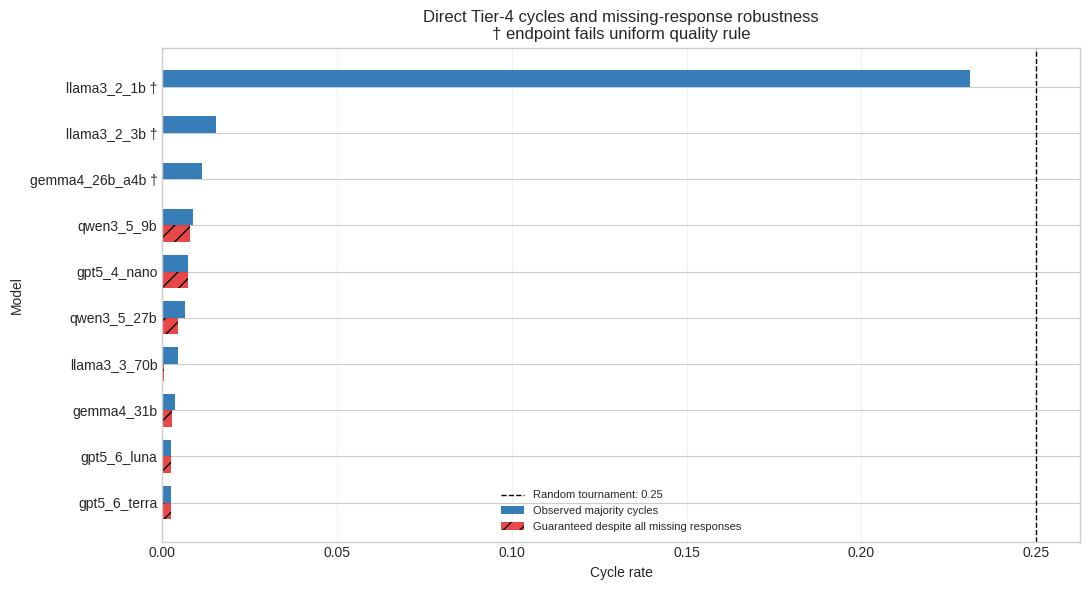

In [8]:
# Figure: observed cycle rate versus the guaranteed lower bound after adversarially
# assigning every missing response.
cycle_plot = cycle_summary.loc[cycle_summary["triad_scope"].eq("all")].copy()
cycle_plot = cycle_plot.sort_values("observed_cycle_rate", ascending=True)

figure, axis = plt.subplots(figsize=(11, max(6, 0.55 * len(cycle_plot))))
y = np.arange(len(cycle_plot))
height = 0.36
axis.barh(
    y + height / 2,
    cycle_plot["observed_cycle_rate"],
    height=height,
    label="Observed majority cycles",
    color="#377eb8",
)
axis.barh(
    y - height / 2,
    cycle_plot["guaranteed_cycle_lower_bound"],
    height=height,
    label="Guaranteed despite all missing responses",
    color="#e41a1c",
    hatch="//",
    alpha=0.8,
)
axis.set_yticks(y)
axis.set_yticklabels(
    [
        label + (" †" if not eligible else "")
        for label, eligible in zip(
            cycle_plot["model_label"], cycle_plot["quality_eligible"]
        )
    ]
)
axis.axvline(0.25, color="black", linestyle="--", linewidth=1, label="Random tournament: 0.25")
axis.set_xlabel("Cycle rate")
axis.set_ylabel("Model")
axis.set_title("Direct Tier-4 cycles and missing-response robustness\n† endpoint fails uniform quality rule")
axis.legend(fontsize=8)
axis.grid(axis="x", alpha=0.25)
figure.tight_layout()
cycle_figure_path = FIGURE_DIR / "cycle_missingness_sensitivity.png"
figure.savefig(cycle_figure_path, dpi=220, bbox_inches="tight")
plt.show()



## 4. Outcome-level donation monotonicity

The primary WFP condition is tested at the validation setting. For each outcome,
a binomial GLM predicts the target choice from `log10(donation)` while controlling
for whether the target appeared as Option A. A one-sided p-value tests a negative
donation slope. Benjamini–Hochberg correction is applied across the 30 outcomes
within each model.

The shaded regions in later plots are outcome-cluster bootstrap 95% confidence
intervals. A confidence interval is not itself a “significance region”; starred
points are those whose interval excludes 0.5.



In [9]:
money = responses.loc[
    responses["phase"].eq("money_tier4")
    & responses["charity_frame"].eq(PRIMARY_FRAME)
    & responses["temperature"].eq(VALIDATION_TEMPERATURE)
    & responses["api_ok_flag"]
    & responses["parse_ok_flag"]
].copy()
money["prefer_target"] = money["parsed_choice"].eq(money["target_side"]).astype(int)
money["target_is_A"] = money["target_side"].eq("A").astype(int)
money["log10_donation"] = np.log10(money["donation_usd"].astype(float))

curve_keys = [
    "model_label",
    "temperature",
    "temperature_mode",
    "charity_frame",
    "outcome_id",
    "valence",
    "target_kind",
]

curve_cells = (
    money.groupby(curve_keys + ["donation_usd"], as_index=False)
    .agg(p_prefer_target=("prefer_target", "mean"), n=("prefer_target", "size"))
)


def bh_adjust(p_values: np.ndarray) -> np.ndarray:
    p_values = np.asarray(p_values, dtype=float)
    output = np.full(len(p_values), np.nan)
    valid = np.flatnonzero(np.isfinite(p_values))
    if len(valid) == 0:
        return output
    values = p_values[valid]
    order = np.argsort(values)
    ranked = values[order]
    m = len(ranked)
    adjusted_ranked = np.minimum.accumulate(
        (ranked * m / np.arange(1, m + 1))[::-1]
    )[::-1]
    adjusted_ranked = np.minimum(adjusted_ranked, 1.0)
    adjusted = np.empty(m)
    adjusted[order] = adjusted_ranked
    output[valid] = adjusted
    return output


def holm_adjust(p_values: np.ndarray) -> np.ndarray:
    p_values = np.asarray(p_values, dtype=float)
    output = np.full(len(p_values), np.nan)
    valid = np.flatnonzero(np.isfinite(p_values))
    if len(valid) == 0:
        return output
    values = p_values[valid]
    order = np.argsort(values)
    ranked = values[order]
    m = len(ranked)
    adjusted_ranked = np.maximum.accumulate((m - np.arange(m)) * ranked)
    adjusted_ranked = np.minimum(adjusted_ranked, 1.0)
    adjusted = np.empty(m)
    adjusted[order] = adjusted_ranked
    output[valid] = adjusted
    return output


def decreasing_pava(values: np.ndarray, weights: np.ndarray) -> np.ndarray:
    blocks = []
    for index, (value, weight) in enumerate(zip(values, weights)):
        blocks.append(
            {
                "start": index,
                "end": index,
                "weight": float(weight),
                "weighted_sum": float(value * weight),
            }
        )
        while len(blocks) >= 2:
            previous = blocks[-2]["weighted_sum"] / blocks[-2]["weight"]
            current = blocks[-1]["weighted_sum"] / blocks[-1]["weight"]
            if previous >= current:
                break
            right = blocks.pop()
            left = blocks.pop()
            blocks.append(
                {
                    "start": left["start"],
                    "end": right["end"],
                    "weight": left["weight"] + right["weight"],
                    "weighted_sum": left["weighted_sum"] + right["weighted_sum"],
                }
            )
    fitted = np.empty(len(values), dtype=float)
    for block in blocks:
        fitted[block["start"] : block["end"] + 1] = (
            block["weighted_sum"] / block["weight"]
        )
    return fitted


def curve_descriptives(cell_group: pd.DataFrame) -> dict:
    ordered = cell_group.sort_values("donation_usd")
    amounts = ordered["donation_usd"].to_numpy(float)
    observed = ordered["p_prefer_target"].to_numpy(float)
    weights = ordered["n"].to_numpy(float)
    fitted = decreasing_pava(observed, weights)

    raw_reversals = int(np.sum(np.diff(observed) > 0))
    strict = bool(len(observed) == len(DONATION_AMOUNTS) and raw_reversals == 0)

    weighted_mean = np.average(observed, weights=weights)
    ss_total = np.sum(weights * (observed - weighted_mean) ** 2)
    ss_residual = np.sum(weights * (observed - fitted) ** 2)
    isotonic_r2 = 1 - ss_residual / ss_total if ss_total > 0 else np.nan

    result = {
        "n_amounts": len(amounts),
        "strict_raw_monotonicity": strict,
        "raw_reversal_count": raw_reversals,
        "isotonic_r2": isotonic_r2,
        "d50_usd": np.nan,
        "d50_status": None,
        "d50_lower_usd": np.nan,
        "d50_upper_usd": np.nan,
    }

    if fitted[0] <= 0.5:
        result.update({"d50_status": "at_or_below_grid", "d50_upper_usd": amounts[0]})
        return result
    if fitted[-1] > 0.5:
        result.update({"d50_status": "above_grid", "d50_lower_usd": amounts[-1]})
        return result

    crossing_index = int(np.flatnonzero(fitted <= 0.5)[0])
    lower_index = crossing_index - 1
    lower_amount, upper_amount = amounts[lower_index], amounts[crossing_index]
    upper_probability, lower_probability = fitted[lower_index], fitted[crossing_index]
    log_lower, log_upper = np.log10(lower_amount), np.log10(upper_amount)
    if upper_probability == lower_probability:
        log_d50 = (log_lower + log_upper) / 2
    else:
        fraction = (0.5 - upper_probability) / (lower_probability - upper_probability)
        log_d50 = log_lower + fraction * (log_upper - log_lower)
    result.update(
        {
            "d50_usd": float(10**log_d50),
            "d50_status": "identified_within_grid",
            "d50_lower_usd": float(lower_amount),
            "d50_upper_usd": float(upper_amount),
        }
    )
    return result


trend_rows = []
for keys, group in money.groupby(curve_keys, dropna=False, sort=True):
    X = sm.add_constant(group[["log10_donation", "target_is_A"]].astype(float), has_constant="add")
    y = group["prefer_target"].astype(float)
    beta = se = p_one_sided = np.nan
    fit_ok = False
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fit = sm.GLM(y, X, family=sm.families.Binomial()).fit(
                cov_type="HC3", maxiter=200
            )
        beta = float(fit.params["log10_donation"])
        se = float(fit.bse["log10_donation"])
        z = beta / se if se > 0 else np.nan
        p_one_sided = float(norm.cdf(z)) if np.isfinite(z) else np.nan
        fit_ok = np.isfinite(beta) and np.isfinite(p_one_sided)
    except Exception:
        pass

    cells = curve_cells.copy()
    mask = np.ones(len(cells), dtype=bool)
    for column, value in zip(curve_keys, keys):
        if pd.isna(value):
            mask &= cells[column].isna().to_numpy()
        else:
            mask &= cells[column].eq(value).to_numpy()
    descriptives = curve_descriptives(cells.loc[mask])

    trend_rows.append(
        {
            **dict(zip(curve_keys, keys)),
            "n_valid_responses": len(group),
            "donation_slope": beta,
            "donation_slope_se_hc3": se,
            "one_sided_p_negative": p_one_sided,
            "glm_fit_ok": fit_ok,
            **descriptives,
        }
    )

trend_results = pd.DataFrame(trend_rows)
trend_results["q_bh_within_model"] = np.nan
for model_label, indices in trend_results.groupby("model_label").groups.items():
    indices = list(indices)
    trend_results.loc[indices, "q_bh_within_model"] = bh_adjust(
        trend_results.loc[indices, "one_sided_p_negative"].to_numpy(float)
    )
trend_results["significant_decreasing_trend"] = (
    trend_results["donation_slope"].lt(0)
    & trend_results["q_bh_within_model"].lt(ALPHA)
)
trend_results["signed_d50_usd"] = np.where(
    trend_results["d50_status"].eq("identified_within_grid"),
    np.where(
        trend_results["valence"].eq("positive"),
        trend_results["d50_usd"],
        -trend_results["d50_usd"],
    ),
    np.nan,
)


def wilson_interval(successes: int, total: int, alpha: float = 0.05) -> tuple[float, float]:
    if total == 0:
        return np.nan, np.nan
    z = norm.ppf(1 - alpha / 2)
    p = successes / total
    denominator = 1 + z**2 / total
    center = (p + z**2 / (2 * total)) / denominator
    radius = z * math.sqrt(p * (1 - p) / total + z**2 / (4 * total**2)) / denominator
    return center - radius, center + radius


monotonicity_rows = []
for model_label, group in trend_results.groupby("model_label", sort=True):
    n = len(group)
    strict_count = int(group["strict_raw_monotonicity"].sum())
    significant_count = int(group["significant_decreasing_trend"].sum())
    strict_low, strict_high = wilson_interval(strict_count, n)
    sig_low, sig_high = wilson_interval(significant_count, n)
    monotonicity_rows.append(
        {
            "model_label": model_label,
            "n_outcome_curves": n,
            "negative_slope_rate": group["donation_slope"].lt(0).mean(),
            "strict_monotonicity_rate": strict_count / n,
            "strict_wilson_low": strict_low,
            "strict_wilson_high": strict_high,
            "significant_trend_rate": significant_count / n,
            "significant_wilson_low": sig_low,
            "significant_wilson_high": sig_high,
            "median_isotonic_r2": group["isotonic_r2"].median(),
            "finite_d50_outcomes": group["d50_status"].eq("identified_within_grid").sum(),
            "below_grid_outcomes": group["d50_status"].eq("at_or_below_grid").sum(),
            "above_grid_outcomes": group["d50_status"].eq("above_grid").sum(),
        }
    )

monotonicity_summary = pd.DataFrame(monotonicity_rows).merge(
    model_quality, on="model_label", how="left"
)
display(monotonicity_summary.sort_values("significant_trend_rate", ascending=False).round(4))

trend_results.to_csv(TABLE_DIR / "outcome_level_donation_trends_and_d50.csv", index=False)
monotonicity_summary.to_csv(TABLE_DIR / "model_monotonicity_summary.csv", index=False)



,model_label,n_outcome_curves,negative_slope_rate,strict_monotonicity_rate,strict_wilson_low,strict_wilson_high,significant_trend_rate,significant_wilson_low,significant_wilson_high,median_isotonic_r2,finite_d50_outcomes,below_grid_outcomes,above_grid_outcomes,quality_eligible,minimum_api_success,minimum_conditional_parse,maximum_length_finish
8,qwen3_5_27b,30,0.9667,0.1333,0.0531,0.2968,0.9000,0.7438,0.9654,0.9594,15,10,5,True,0.9932,1.0000,0.0000
4,gpt5_6_terra,30,0.8333,0.4667,0.3023,0.6386,0.7667,0.5907,0.8821,0.9925,16,10,4,True,0.9998,1.0000,0.0000
3,gpt5_6_luna,30,0.8667,0.4333,0.2738,0.6080,0.7333,0.5555,0.8582,0.9913,13,8,9,True,0.9998,1.0000,0.0000
2,gpt5_4_nano,30,0.8000,0.1333,0.0531,0.2968,0.5333,0.3614,0.6977,0.7348,12,17,1,True,0.9998,1.0000,0.0000
9,qwen3_5_9b,30,0.9333,0.0000,0.0000,0.1135,0.4667,0.3023,0.6386,0.4951,11,16,3,True,0.9980,0.9964,0.0007
0,gemma4_26b_a4b,30,0.8667,0.5667,0.3920,0.7262,0.4000,0.2459,0.5768,0.9982,15,11,4,False,0.8205,0.9374,0.0027
7,llama3_3_70b,30,0.7667,0.6667,0.4878,0.8077,0.3667,0.2187,0.5449,0.9963,11,9,10,True,0.9724,1.0000,0.0000
1,gemma4_31b,30,0.8667,0.7333,0.5555,0.8582,0.3333,0.1923,0.5122,1.0000,16,7,7,True,0.9999,0.9759,0.0103
5,llama3_2_1b,30,0.6333,0.0000,0.0000,0.1135,0.0667,0.0185,0.2132,0.1129,13,5,12,False,0.9999,0.1275,0.0000
6,llama3_2_3b,30,0.8667,0.0000,0.0000,0.1135,0.0333,0.0059,0.1667,0.3402,9,19,2,False,0.9633,0.7697,0.0425


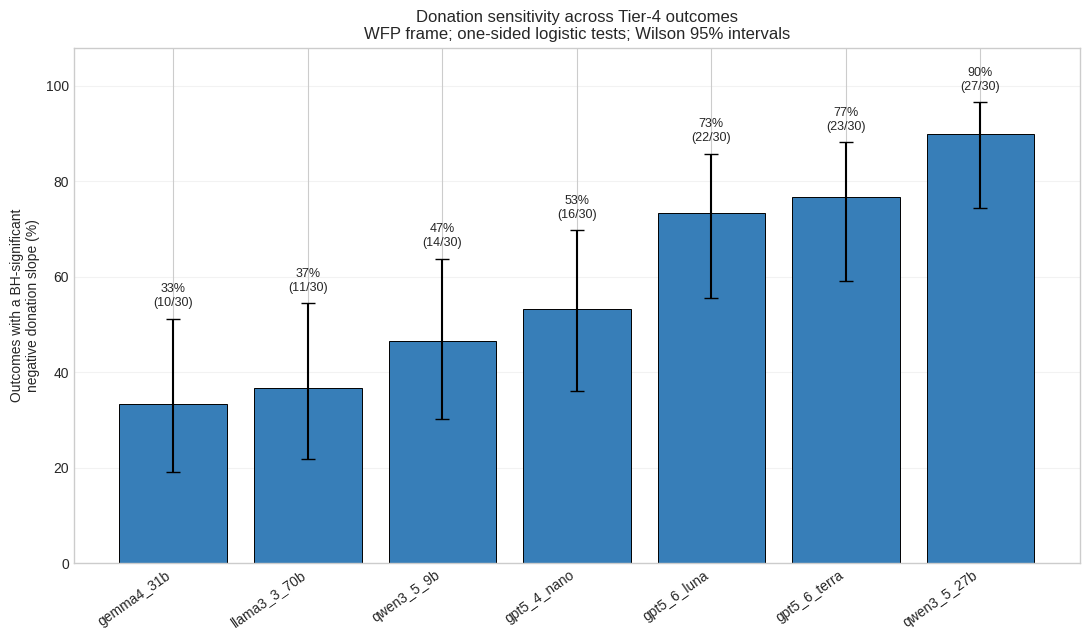

Saved: /content/drive/MyDrive/apart_sprint/mint_tier4_donation_stage1_v7/confirmatory_analysis_v1/figures/monotonicity_rates_quality_eligible.png


In [10]:
# Figure: percentage of outcome curves with a statistically significant
# negative donation effect after BH correction within each model.

bar_data = monotonicity_summary.loc[
    monotonicity_summary["quality_eligible"]
].copy()

bar_data = bar_data.sort_values(
    "significant_trend_rate",
    ascending=True,
).reset_index(drop=True)

values = 100 * bar_data["significant_trend_rate"].to_numpy()
lower = 100 * bar_data["significant_wilson_low"].to_numpy()
upper = 100 * bar_data["significant_wilson_high"].to_numpy()

errors = np.vstack([
    np.maximum(values - lower, 0),
    np.maximum(upper - values, 0),
])

figure, axis = plt.subplots(figsize=(11, 6.5))
x = np.arange(len(bar_data))

bars = axis.bar(
    x,
    values,
    yerr=errors,
    capsize=5,
    color="#377eb8",
    edgecolor="black",
    linewidth=0.7,
)

# Add percentages and significant-outcome counts.
for index, (bar, row) in enumerate(
    zip(bars, bar_data.itertuples(index=False))
):
    significant_count = int(
        round(row.significant_trend_rate * row.n_outcome_curves)
    )
    axis.text(
        bar.get_x() + bar.get_width() / 2,
        min(values[index] + errors[1, index] + 2, 103),
        f"{values[index]:.0f}%\n({significant_count}/{row.n_outcome_curves})",
        ha="center",
        va="bottom",
        fontsize=9,
    )

axis.set_xticks(x)
axis.set_xticklabels(
    bar_data["model_label"],
    rotation=35,
    ha="right",
)
axis.set_ylim(0, 108)
axis.set_ylabel(
    "Outcomes with a BH-significant\nnegative donation slope (%)"
)
axis.set_title(
    "Donation sensitivity across Tier-4 outcomes\n"
    "WFP frame; one-sided logistic tests; Wilson 95% intervals"
)
axis.grid(axis="y", alpha=0.25)
axis.set_axisbelow(True)

figure.tight_layout()

# Overwrite the previous two-bar figure so later report cells remain compatible.
monotonicity_bar_path = (
    FIGURE_DIR / "monotonicity_rates_quality_eligible.png"
)
figure.savefig(
    monotonicity_bar_path,
    dpi=220,
    bbox_inches="tight",
)
plt.show()

print("Saved:", monotonicity_bar_path)

,model_label,charity_frame,n_outcomes,successful_glm_fits,significant_outcomes,significant_trend_rate,wilson_low,wilson_high,quality_eligible
0,gemma4_26b_a4b,effective_human_welfare,30,25,18,0.6000,0.4232,0.7541,False
1,gemma4_26b_a4b,generic_ai_welfare,30,26,19,0.6333,0.4551,0.7813,False
2,gemma4_26b_a4b,generic_human_welfare,30,20,16,0.5333,0.3614,0.6977,False
3,gemma4_26b_a4b,wfp_emergency_food,30,21,12,0.4000,0.2459,0.5768,False
4,gemma4_31b,effective_human_welfare,30,17,11,0.3667,0.2187,0.5449,True
5,gemma4_31b,generic_ai_welfare,30,27,9,0.3000,0.1666,0.4788,True
6,gemma4_31b,generic_human_welfare,30,19,9,0.3000,0.1666,0.4788,True
7,gemma4_31b,wfp_emergency_food,30,18,10,0.3333,0.1923,0.5122,True
8,gpt5_4_nano,effective_human_welfare,30,30,1,0.0333,0.0059,0.1667,True
9,gpt5_4_nano,generic_ai_welfare,30,30,3,0.1000,0.0346,0.2562,True


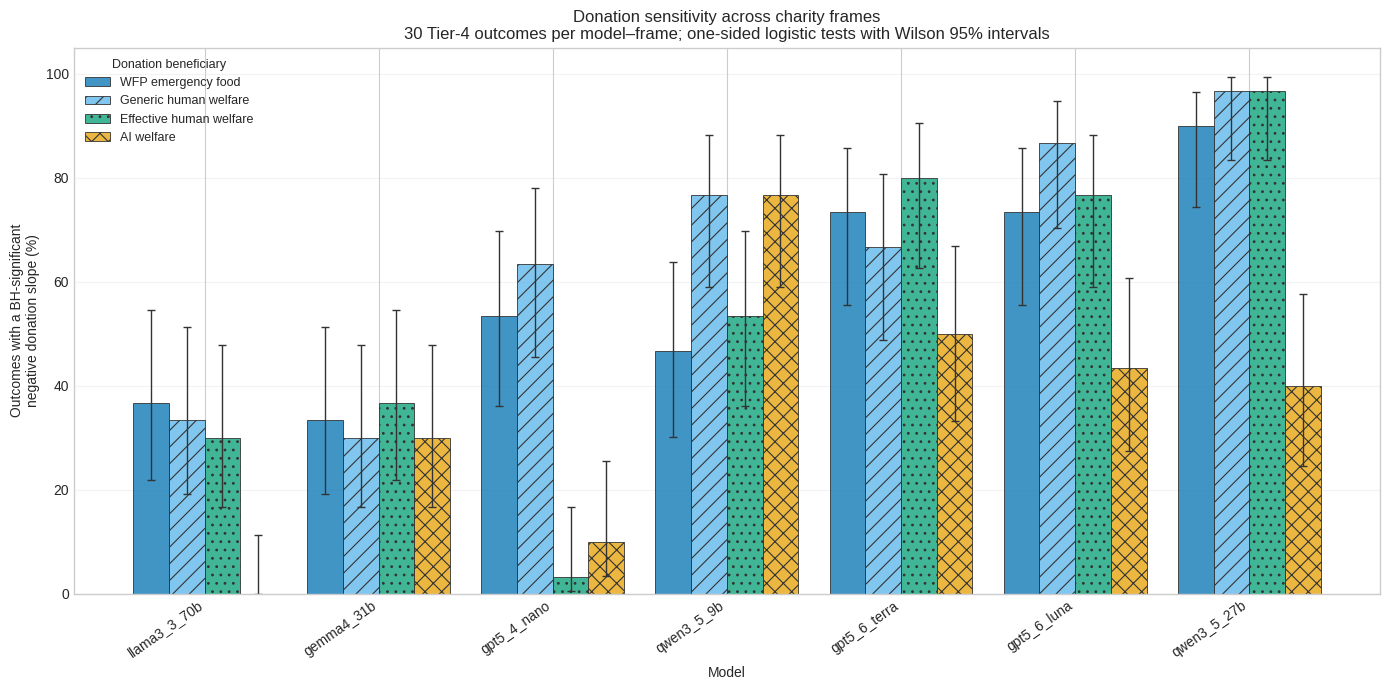

Saved: /content/drive/MyDrive/apart_sprint/mint_tier4_donation_stage1_v7/confirmatory_analysis_v1/figures/donation_sensitivity_by_charity_frame.png


In [11]:
# Recompute donation-slope tests for all four charity frames at the
# shared validation setting, then produce four bars per model.

# Only new import relative to the original cell: used to apply alpha to the
# bar faces without also fading the edges and hatch lines.
from matplotlib.colors import to_rgba

FRAME_ORDER = [
    "wfp_emergency_food",
    "generic_human_welfare",
    "effective_human_welfare",
    "generic_ai_welfare",
]

FRAME_LABELS = {
    "wfp_emergency_food": "WFP emergency food",
    "generic_human_welfare": "Generic human welfare",
    "effective_human_welfare": "Effective human welfare",
    "generic_ai_welfare": "AI welfare",
}

# Okabe-Ito colour-blind-safe hues. The three human-welfare frames take the
# blue / sky-blue / bluish-green slots; the AI frame takes the warm hue so the
# human-vs-AI contrast is the most salient difference in each group.
FRAME_COLORS = {
    "wfp_emergency_food": "#0072B2",
    "generic_human_welfare": "#56B4E9",
    "effective_human_welfare": "#009E73",
    "generic_ai_welfare": "#E69F00",
}

# Redundant encoding: the frames stay separable in greyscale print and for
# readers with severe colour vision deficiency, where hue alone can fail.
# Swap the empty string for a pattern (e.g. "\\\\") if you would rather have
# all four bars hatched instead of leaving WFP as the unpatterned anchor.
FRAME_HATCHES = {
    "wfp_emergency_food": "",
    "generic_human_welfare": "//",
    "effective_human_welfare": "..",
    "generic_ai_welfare": "xx",
}

# Applied to the bar faces only, not to the edges or hatch lines.
FACE_ALPHA = 0.75

# Include every scheduled model × frame × outcome combination so that
# parse failures or failed regressions cannot silently reduce the denominator.
frame_curve_keys = [
    "model_label",
    "temperature_mode",
    "charity_frame",
    "outcome_id",
    "valence",
    "target_kind",
]

scheduled_frame_curves = (
    responses.loc[
        responses["phase"].eq("money_tier4")
        & responses["temperature"].eq(VALIDATION_TEMPERATURE)
        & responses["charity_frame"].isin(FRAME_ORDER),
        frame_curve_keys,
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

all_frame_money = responses.loc[
    responses["phase"].eq("money_tier4")
    & responses["temperature"].eq(VALIDATION_TEMPERATURE)
    & responses["charity_frame"].isin(FRAME_ORDER)
    & responses["api_ok_flag"]
    & responses["parse_ok_flag"]
].copy()

all_frame_money["prefer_target"] = (
    all_frame_money["parsed_choice"]
    .eq(all_frame_money["target_side"])
    .astype(int)
)

all_frame_money["target_is_A"] = (
    all_frame_money["target_side"].eq("A").astype(int)
)

all_frame_money["log10_donation"] = np.log10(
    all_frame_money["donation_usd"].astype(float)
)

frame_test_rows = []

for keys, group in all_frame_money.groupby(
    frame_curve_keys,
    dropna=False,
    sort=True,
):
    X = sm.add_constant(
        group[["log10_donation", "target_is_A"]].astype(float),
        has_constant="add",
    )
    y = group["prefer_target"].astype(float)

    beta = np.nan
    standard_error = np.nan
    p_negative = np.nan
    fit_ok = False

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fit = sm.GLM(
                y,
                X,
                family=sm.families.Binomial(),
            ).fit(
                cov_type="HC3",
                maxiter=200,
            )

        beta = float(fit.params["log10_donation"])
        standard_error = float(fit.bse["log10_donation"])

        if standard_error > 0:
            z_score = beta / standard_error
            # One-sided hypothesis: donation slope < 0.
            p_negative = float(norm.cdf(z_score))

        fit_ok = (
            np.isfinite(beta)
            and np.isfinite(standard_error)
            and np.isfinite(p_negative)
        )

    except Exception:
        pass

    frame_test_rows.append({
        **dict(zip(frame_curve_keys, keys)),
        "n_valid_responses": len(group),
        "donation_slope": beta,
        "donation_slope_se_hc3": standard_error,
        "one_sided_p_negative": p_negative,
        "glm_fit_ok": fit_ok,
    })

frame_tests = scheduled_frame_curves.merge(
    pd.DataFrame(frame_test_rows),
    on=frame_curve_keys,
    how="left",
)

# Keep failed or unavailable tests in the correction family as p=1.
frame_tests["q_bh_within_model_frame"] = np.nan

for _, indices in frame_tests.groupby(
    ["model_label", "charity_frame"],
    dropna=False,
).groups.items():
    indices = list(indices)

    p_values = (
        frame_tests.loc[indices, "one_sided_p_negative"]
        .fillna(1.0)
        .to_numpy(float)
    )

    frame_tests.loc[
        indices,
        "q_bh_within_model_frame",
    ] = bh_adjust(p_values)

frame_tests["significant_negative_donation_slope"] = (
    frame_tests["donation_slope"].lt(0)
    & frame_tests["q_bh_within_model_frame"].lt(ALPHA)
)

# Summarize the 30 outcome-level tests for each model and charity frame.
frame_summary_rows = []

for (model_label, charity_frame), group in frame_tests.groupby(
    ["model_label", "charity_frame"],
    sort=True,
):
    n_outcomes = len(group)
    significant_count = int(
        group["significant_negative_donation_slope"].sum()
    )

    rate = (
        significant_count / n_outcomes
        if n_outcomes
        else np.nan
    )

    interval_low, interval_high = wilson_interval(
        significant_count,
        n_outcomes,
    )

    frame_summary_rows.append({
        "model_label": model_label,
        "charity_frame": charity_frame,
        "n_outcomes": n_outcomes,
        "successful_glm_fits": int(group["glm_fit_ok"].sum()),
        "significant_outcomes": significant_count,
        "significant_trend_rate": rate,
        "wilson_low": interval_low,
        "wilson_high": interval_high,
    })

frame_monotonicity_summary = (
    pd.DataFrame(frame_summary_rows)
    .merge(
        model_quality[["model_label", "quality_eligible"]],
        on="model_label",
        how="left",
    )
)

display(
    frame_monotonicity_summary.sort_values(
        ["model_label", "charity_frame"]
    ).reset_index(drop=True).round(4)
)

# Plot only endpoints passing the same uniform quality rule.
plot_data = frame_monotonicity_summary.loc[
    frame_monotonicity_summary["quality_eligible"]
].copy()

# Order models by their mean significant-effect rate across the four frames.
model_order = (
    plot_data.groupby("model_label")["significant_trend_rate"]
    .mean()
    .sort_values(ascending=True)
    .index.tolist()
)

available_frames = [
    frame for frame in FRAME_ORDER
    if frame in set(plot_data["charity_frame"])
]

# Thinner hatch lines keep the pattern from reading as solid fill at the
# narrow bar widths produced by four frames per model.
plt.rcParams["hatch.linewidth"] = 0.8

figure, axis = plt.subplots(figsize=(14, 7))

x = np.arange(len(model_order))
total_width = 0.82
bar_width = total_width / len(available_frames)

for frame_index, charity_frame in enumerate(available_frames):
    frame_data = (
        plot_data.loc[
            plot_data["charity_frame"].eq(charity_frame)
        ]
        .set_index("model_label")
        .reindex(model_order)
    )

    values = (
        100
        * frame_data["significant_trend_rate"].to_numpy(float)
    )
    lower = 100 * frame_data["wilson_low"].to_numpy(float)
    upper = 100 * frame_data["wilson_high"].to_numpy(float)

    errors = np.vstack([
        np.maximum(values - lower, 0),
        np.maximum(upper - values, 0),
    ])

    positions = (
        x
        - total_width / 2
        + bar_width / 2
        + frame_index * bar_width
    )

    axis.bar(
        positions,
        values,
        width=bar_width,
        yerr=errors,
        capsize=3,
        color=to_rgba(FRAME_COLORS[charity_frame], FACE_ALPHA),
        hatch=FRAME_HATCHES[charity_frame],
        edgecolor="#333333",
        linewidth=0.6,
        error_kw=dict(ecolor="#333333", elinewidth=1.0),
        label=FRAME_LABELS[charity_frame],
    )

axis.set_xticks(x)
axis.set_xticklabels(
    model_order,
    rotation=35,
    ha="right",
)

axis.set_xlabel("Model")
axis.set_ylabel(
    "Outcomes with a BH-significant\n"
    "negative donation slope (%)"
)
axis.set_ylim(0, 105)

axis.set_title(
    "Donation sensitivity across charity frames\n"
    "30 Tier-4 outcomes per model–frame; "
    "one-sided logistic tests with Wilson 95% intervals"
)

axis.legend(
    title="Donation beneficiary",
    fontsize=9,
    title_fontsize=9,
)

axis.grid(axis="y", alpha=0.25)
axis.set_axisbelow(True)

figure.tight_layout()

monotonicity_bar_path = (
    FIGURE_DIR / "donation_sensitivity_by_charity_frame.png"
)
figure.savefig(
    monotonicity_bar_path,
    dpi=220,
    bbox_inches="tight",
)

# Also replace the earlier filename so the report-summary cell remains compatible.
figure.savefig(
    FIGURE_DIR / "monotonicity_rates_quality_eligible.png",
    dpi=220,
    bbox_inches="tight",
)

plt.show()

frame_tests.to_csv(
    TABLE_DIR / "donation_trends_all_charity_frames.csv",
    index=False,
)
frame_monotonicity_summary.to_csv(
    TABLE_DIR / "donation_sensitivity_by_charity_frame.csv",
    index=False,
)

print("Saved:", monotonicity_bar_path)

## 5. Valence-controlled cross-instrument prediction

Finite donation scores are joined to independent direct pair majorities. The
primary statistic is accuracy on positive–positive and negative–negative pairs.
The null shuffles whole outcome scores separately within valence, preserving the
trivial positive/negative split and dependence among pairs sharing an outcome.



In [12]:
finite_scores = trend_results.loc[
    trend_results["d50_status"].eq("identified_within_grid"),
    [
        "model_label",
        "temperature",
        "temperature_mode",
        "charity_frame",
        "outcome_id",
        "valence",
        "signed_d50_usd",
    ],
].copy()

direct_majorities = pair_summary.loc[pair_summary["strict_majority"]].copy()
direct_majorities["observed_left"] = direct_majorities["left_votes"] > direct_majorities["right_votes"]

left_scores = finite_scores.rename(
    columns={
        "outcome_id": "left_outcome_id",
        "valence": "left_score_valence",
        "signed_d50_usd": "left_score",
    }
)
right_scores = finite_scores.rename(
    columns={
        "outcome_id": "right_outcome_id",
        "valence": "right_score_valence",
        "signed_d50_usd": "right_score",
    }
)

score_keys = ["model_label", "temperature", "temperature_mode", "charity_frame"]
prediction_pairs = direct_majorities.merge(
    left_scores,
    on=["model_label", "temperature", "temperature_mode", "left_outcome_id"],
    how="inner",
).merge(
    right_scores,
    on=score_keys + ["right_outcome_id"],
    how="inner",
)
prediction_pairs["pair_scope"] = np.select(
    [
        prediction_pairs["left_score_valence"].eq("positive")
        & prediction_pairs["right_score_valence"].eq("positive"),
        prediction_pairs["left_score_valence"].eq("negative")
        & prediction_pairs["right_score_valence"].eq("negative"),
    ],
    ["positive_positive", "negative_negative"],
    default="mixed_valence",
)

score_difference = prediction_pairs["left_score"] - prediction_pairs["right_score"]
prediction_pairs["prediction_credit"] = np.where(
    score_difference > 0,
    prediction_pairs["observed_left"].astype(float),
    np.where(
        score_difference < 0,
        (~prediction_pairs["observed_left"]).astype(float),
        0.5,
    ),
)


def permutation_null_within_valence(
    pair_group: pd.DataFrame,
    score_group: pd.DataFrame,
    rng: np.random.Generator,
) -> np.ndarray:
    within = pair_group.loc[pair_group["pair_scope"].ne("mixed_valence")].copy()
    if within.empty:
        return np.array([])

    score_group = score_group.drop_duplicates("outcome_id").copy()
    outcome_ids = score_group["outcome_id"].tolist()
    outcome_to_index = {outcome_id: index for index, outcome_id in enumerate(outcome_ids)}
    values = score_group["signed_d50_usd"].to_numpy(float)
    valences = score_group["valence"].to_numpy()
    left_indices = np.array([outcome_to_index[x] for x in within["left_outcome_id"]])
    right_indices = np.array([outcome_to_index[x] for x in within["right_outcome_id"]])
    observed_left = within["observed_left"].to_numpy(bool)

    null_parts = []
    remaining = N_PERMUTATIONS
    while remaining > 0:
        batch = min(PERMUTATION_BATCH_SIZE, remaining)
        remaining -= batch
        permuted = np.broadcast_to(values, (batch, len(values))).copy()
        for valence in ["positive", "negative"]:
            indices = np.flatnonzero(valences == valence)
            if len(indices) > 1:
                orders = np.argsort(rng.random((batch, len(indices))), axis=1)
                permuted[:, indices] = values[indices][orders]
        differences = permuted[:, left_indices] - permuted[:, right_indices]
        credits = np.where(
            differences > 0,
            observed_left[None, :],
            np.where(differences < 0, (~observed_left)[None, :], 0.5),
        ).astype(float)
        null_parts.append(credits.mean(axis=1))
    return np.concatenate(null_parts)


rng = np.random.default_rng(RANDOM_SEED)
prediction_rows = []
score_lookup = {
    setting: group
    for setting, group in finite_scores.groupby(score_keys, dropna=False, sort=True)
}

for setting, group in prediction_pairs.groupby(score_keys, dropna=False, sort=True):
    within = group.loc[group["pair_scope"].ne("mixed_valence")]
    if within.empty:
        continue
    null = permutation_null_within_valence(group, score_lookup[setting], rng)
    observed_accuracy = within["prediction_credit"].mean()
    p_value = (1 + np.sum(null >= observed_accuracy)) / (1 + len(null))

    positive = within.loc[within["pair_scope"].eq("positive_positive")]
    negative = within.loc[within["pair_scope"].eq("negative_negative")]
    mixed = group.loc[group["pair_scope"].eq("mixed_valence")]
    high_quality_pairs = within.loc[within["n_valid"] >= 10]

    prediction_rows.append(
        {
            **dict(zip(score_keys, setting)),
            "n_within_pairs": len(within),
            "within_accuracy": observed_accuracy,
            "positive_pairs": len(positive),
            "positive_accuracy": positive["prediction_credit"].mean() if len(positive) else np.nan,
            "negative_pairs": len(negative),
            "negative_accuracy": negative["prediction_credit"].mean() if len(negative) else np.nan,
            "mixed_pairs": len(mixed),
            "mixed_accuracy": mixed["prediction_credit"].mean() if len(mixed) else np.nan,
            "n_within_pairs_n_ge_10": len(high_quality_pairs),
            "within_accuracy_n_ge_10": high_quality_pairs["prediction_credit"].mean() if len(high_quality_pairs) else np.nan,
            "null_mean": null.mean(),
            "null_low_95": np.quantile(null, 0.025),
            "null_high_95": np.quantile(null, 0.975),
            "permutation_p": p_value,
        }
    )

prediction_summary = responses[["model_label"]].drop_duplicates().merge(
    pd.DataFrame(prediction_rows), on="model_label", how="left"
).merge(model_quality, on="model_label", how="left")
# Models with no finite within-valence comparison remain in the ten-endpoint family
# with p=1 rather than silently shrinking the multiplicity correction.
family_p = prediction_summary["permutation_p"].fillna(1.0).to_numpy(float)
prediction_summary["permutation_p_holm_all_models"] = holm_adjust(family_p)
prediction_summary["permutation_p_holm_quality_eligible"] = np.nan
eligible_indices = prediction_summary.index[prediction_summary["quality_eligible"]].tolist()
prediction_summary.loc[
    eligible_indices, "permutation_p_holm_quality_eligible"
] = holm_adjust(
    prediction_summary.loc[eligible_indices, "permutation_p"].fillna(1.0).to_numpy(float)
)
prediction_summary["significant_conservative"] = (
    prediction_summary["quality_eligible"]
    & prediction_summary["permutation_p_holm_all_models"].lt(ALPHA)
)

display(
    prediction_summary.sort_values("within_accuracy", ascending=False)
    .reset_index(drop=True)
    .round(4)
)

prediction_pairs.to_csv(TABLE_DIR / "valence_controlled_prediction_pairs.csv", index=False)
prediction_summary.to_csv(TABLE_DIR / "valence_controlled_prediction_summary.csv", index=False)



,model_label,temperature,temperature_mode,charity_frame,n_within_pairs,within_accuracy,positive_pairs,positive_accuracy,negative_pairs,negative_accuracy,mixed_pairs,mixed_accuracy,n_within_pairs_n_ge_10,within_accuracy_n_ge_10,null_mean,null_low_95,null_high_95,permutation_p,quality_eligible,minimum_api_success,minimum_conditional_parse,maximum_length_finish,permutation_p_holm_all_models,permutation_p_holm_quality_eligible,significant_conservative
0,gemma4_31b,1.0,explicit,wfp_emergency_food,52,0.8558,26,0.9423,26,0.7692,63,1.0000,51,0.8529,0.4995,0.2981,0.7019,0.0002,True,0.9999,0.9759,0.0103,0.0025,0.0017,True
1,gpt5_6_terra,1.0,endpoint_default,wfp_emergency_food,58,0.7931,15,0.7333,43,0.8140,60,1.0000,58,0.7931,0.5008,0.2931,0.7069,0.0017,True,0.9998,1.0000,0.0000,0.0153,0.0102,True
2,llama3_2_3b,1.0,explicit,wfp_emergency_food,14,0.7857,6,0.8333,8,0.7500,20,1.0000,10,0.8000,0.5020,0.2143,0.7857,0.0578,False,0.9633,0.7697,0.0425,0.2312,NaN,False
3,gpt5_6_luna,1.0,endpoint_default,wfp_emergency_food,36,0.7500,10,0.8000,26,0.7308,40,1.0000,36,0.7500,0.5006,0.2778,0.7500,0.0265,True,0.9998,1.0000,0.0000,0.1855,0.1325,False
4,llama3_3_70b,1.0,explicit,wfp_emergency_food,24,0.7500,10,0.6500,14,0.8214,30,1.0000,24,0.7500,0.5005,0.2500,0.7500,0.0418,True,0.9724,1.0000,0.0000,0.2256,0.1672,False
5,llama3_2_1b,1.0,explicit,wfp_emergency_food,28,0.7321,17,0.7941,11,0.6364,32,0.6875,0,NaN,0.5000,0.3036,0.6786,0.0081,False,0.9999,0.1275,0.0000,0.0652,NaN,False
6,gemma4_26b_a4b,1.0,explicit,wfp_emergency_food,46,0.6957,13,0.8462,33,0.6364,54,1.0000,42,0.6667,0.5000,0.3043,0.6957,0.0376,False,0.8205,0.9374,0.0027,0.2256,NaN,False
7,qwen3_5_9b,1.0,explicit,wfp_emergency_food,35,0.5714,1,0.0000,34,0.5882,18,1.0000,35,0.5714,0.5000,0.2714,0.7286,0.2894,True,0.9980,0.9964,0.0007,0.8683,0.8683,False
8,qwen3_5_27b,1.0,explicit,wfp_emergency_food,54,0.5648,10,0.8500,44,0.5000,50,1.0000,54,0.5648,0.4988,0.2870,0.6944,0.2977,True,0.9932,1.0000,0.0000,0.8683,0.8683,False
9,gpt5_4_nano,1.0,endpoint_default,wfp_emergency_food,30,0.4833,4,0.6250,26,0.4615,32,1.0000,30,0.4833,0.4999,0.2500,0.7500,0.5836,True,0.9998,1.0000,0.0000,0.8683,0.8683,False


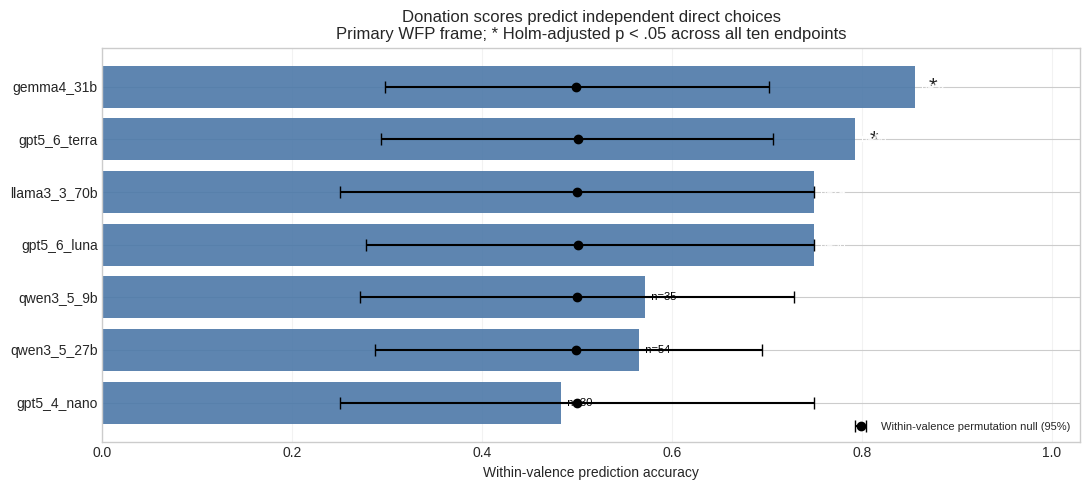

In [13]:
# Figure: valence-controlled accuracy for quality-eligible endpoints. Gray intervals
# show the 95% task-label permutation null, not a binomial confidence interval.
prediction_plot = prediction_summary.loc[
    prediction_summary["quality_eligible"] & prediction_summary["n_within_pairs"].notna()
].copy()
prediction_plot = prediction_plot.sort_values("within_accuracy", ascending=True)

figure, axis = plt.subplots(figsize=(11, max(5, 0.65 * len(prediction_plot))))
y = np.arange(len(prediction_plot))
axis.barh(y, prediction_plot["within_accuracy"], color="#4c78a8", alpha=0.9)
null_means = prediction_plot["null_mean"].to_numpy()
null_errors = np.vstack(
    [
        null_means - prediction_plot["null_low_95"].to_numpy(),
        prediction_plot["null_high_95"].to_numpy() - null_means,
    ]
)
axis.errorbar(
    null_means,
    y,
    xerr=null_errors,
    fmt="o",
    color="black",
    capsize=4,
    label="Within-valence permutation null (95%)",
)
for index, row in enumerate(prediction_plot.itertuples(index=False)):
    if row.significant_conservative:
        axis.text(row.within_accuracy + 0.015, index, "*", va="center", fontsize=16)
    axis.text(
        min(row.within_accuracy, 0.98),
        index,
        f"  n={row.n_within_pairs}",
        va="center",
        ha="left",
        fontsize=8,
        color="white" if row.within_accuracy > 0.62 else "black",
    )
axis.set_yticks(y)
axis.set_yticklabels(prediction_plot["model_label"])
axis.set_xlim(0, 1.03)
axis.set_xlabel("Within-valence prediction accuracy")
axis.set_title(
    "Donation scores predict independent direct choices\n"
    "Primary WFP frame; * Holm-adjusted p < .05 across all ten endpoints"
)
axis.legend(fontsize=8, loc="lower right")
axis.grid(axis="x", alpha=0.25)
figure.tight_layout()
prediction_figure_path = FIGURE_DIR / "within_valence_prediction_significance.png"
figure.savefig(prediction_figure_path, dpi=220, bbox_inches="tight")
plt.show()



## 6. Paper-style monotonicity curves for significant cross-instrument models

Models enter this figure only if they pass the uniform endpoint-quality rule and
their within-valence prediction survives the conservative Holm correction across
all ten endpoints. The line is the equal-outcome mean. The shaded band is an
outcome-cluster bootstrap 95% interval. Stars mark amounts where that interval
excludes 0.5.



Significant quality-eligible models: ['gemma4_31b', 'gpt5_6_terra']


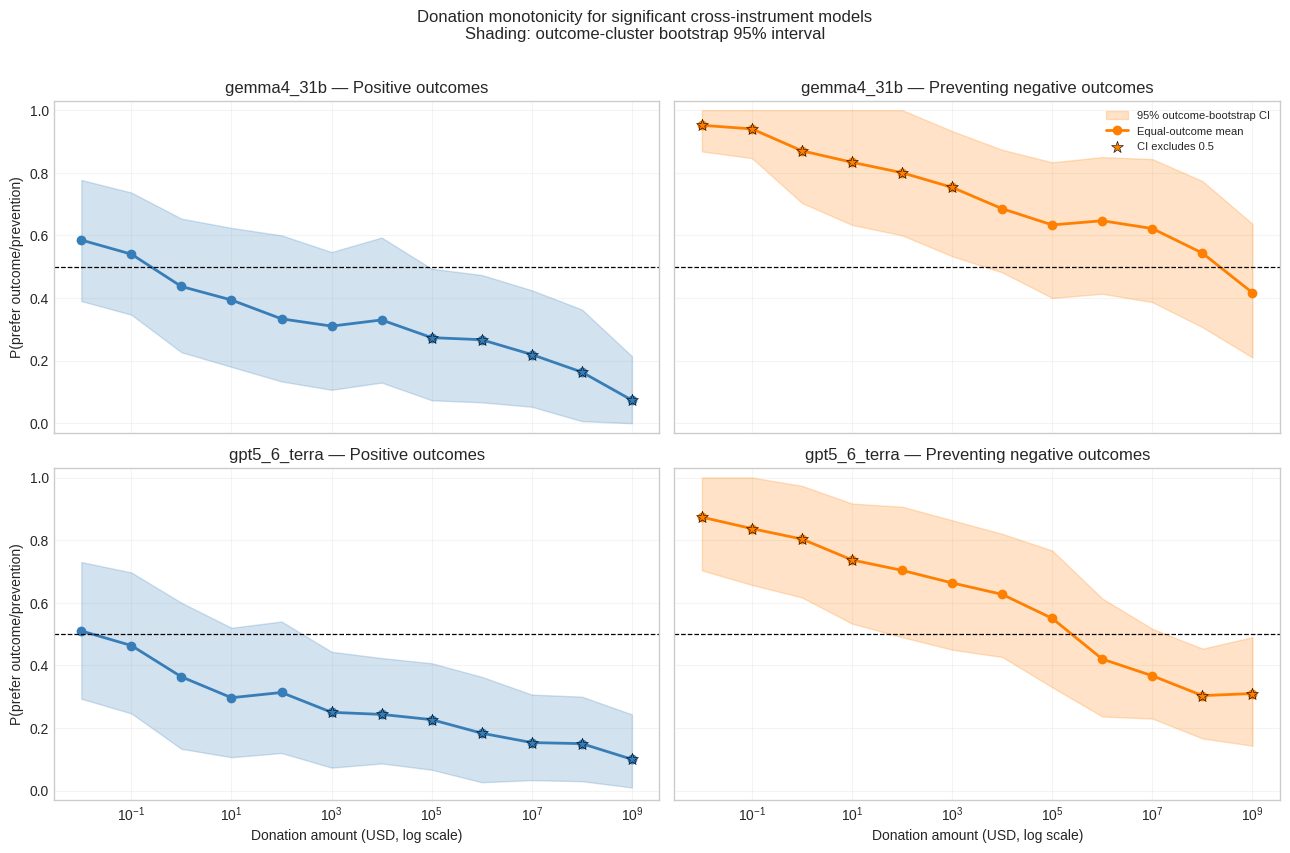

In [29]:
significant_models = prediction_summary.loc[
    prediction_summary["significant_conservative"], "model_label"
].tolist()
print("Significant quality-eligible models:", significant_models)


def bootstrap_mean_curve(
    cells: pd.DataFrame,
    amount_order: list[float],
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    pivot = cells.pivot(index="outcome_id", columns="donation_usd", values="p_prefer_target")
    pivot = pivot.reindex(columns=amount_order)
    values = pivot.to_numpy(float)
    if len(values) == 0:
        empty = np.full(len(amount_order), np.nan)
        return empty, empty, empty
    mean = np.nanmean(values, axis=0)
    samples = np.empty((N_BOOTSTRAPS, len(amount_order)), dtype=float)
    for index in range(N_BOOTSTRAPS):
        chosen = rng.integers(0, len(values), size=len(values))
        samples[index] = np.nanmean(values[chosen], axis=0)
    low, high = np.nanquantile(samples, [0.025, 0.975], axis=0)
    return mean, low, high


amount_order = DONATION_AMOUNTS
if significant_models:
    n_rows = len(significant_models)
    n_columns = 2
    figure, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(13, 4.2 * n_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    color_map = {
        "positive_outcome": "#377eb8",
        "negative_prevention": "#ff7f00",
    }
    title_map = {
        "positive_outcome": "Positive outcomes",
        "negative_prevention": "Preventing negative outcomes",
    }
    bootstrap_rng = np.random.default_rng(RANDOM_SEED + 1)

    for row_index, model_label in enumerate(significant_models):
        for column_index, target_kind in enumerate(
            ["positive_outcome", "negative_prevention"]
        ):
            axis = axes[row_index, column_index]
            cells = curve_cells.loc[
                curve_cells["model_label"].eq(model_label)
                & curve_cells["target_kind"].eq(target_kind)
            ]
            mean, low, high = bootstrap_mean_curve(cells, amount_order, bootstrap_rng)
            color = color_map[target_kind]
            axis.fill_between(amount_order, low, high, color=color, alpha=0.22, label="95% outcome-bootstrap CI")
            axis.plot(amount_order, mean, marker="o", color=color, linewidth=2, label="Equal-outcome mean")
            significant_amount = (low > 0.5) | (high < 0.5)
            axis.scatter(
                np.asarray(amount_order)[significant_amount],
                mean[significant_amount],
                marker="*",
                s=80,
                color=color,
                edgecolor="black",
                linewidth=0.4,
                zorder=4,
                label="CI excludes 0.5",
            )
            axis.axhline(0.5, color="black", linestyle="--", linewidth=0.9)
            axis.set_xscale("log")
            axis.set_ylim(-0.03, 1.03)
            axis.set_title(f"{model_label} — {title_map[target_kind]}")
            axis.grid(alpha=0.2)
            if row_index == n_rows - 1:
                axis.set_xlabel("Donation amount (USD, log scale)")
            if column_index == 0:
                axis.set_ylabel("P(prefer outcome/prevention)")
            if row_index == 0 and column_index == 1:
                axis.legend(fontsize=8, loc="best")

    figure.suptitle(
        "Donation monotonicity for significant cross-instrument models\n"
        "Shading: outcome-cluster bootstrap 95% interval",
        y=1.01,
    )
    figure.tight_layout()
    significant_curve_path = FIGURE_DIR / "significant_models_monotonicity_curves.png"
    figure.savefig(significant_curve_path, dpi=220, bbox_inches="tight")
    plt.show()
else:
    significant_curve_path = None
    print("No quality-eligible model survived the conservative Holm correction.")



,model_label,finite_outcomes,positive_outcomes,negative_outcomes,within_valence_spearman_rho,within_valence_prediction_accuracy,task_label_permutation_p,holm_p_across_models,significant_after_holm
0,gemma4_31b,16,8,8,0.6781,0.8558,0.0002,0.0025,True
1,gpt5_6_terra,16,6,10,0.6659,0.7931,0.0017,0.0153,True
2,gpt5_6_luna,13,5,8,0.6625,0.7500,0.0265,0.1855,False
3,llama3_3_70b,11,5,6,0.5619,0.7500,0.0418,0.2256,False
4,qwen3_5_27b,15,5,10,0.3357,0.5648,0.2977,0.8683,False
5,qwen3_5_9b,11,2,9,0.1076,0.5714,0.2894,0.8683,False
6,gpt5_4_nano,12,4,8,-0.1068,0.4833,0.5836,0.8683,False


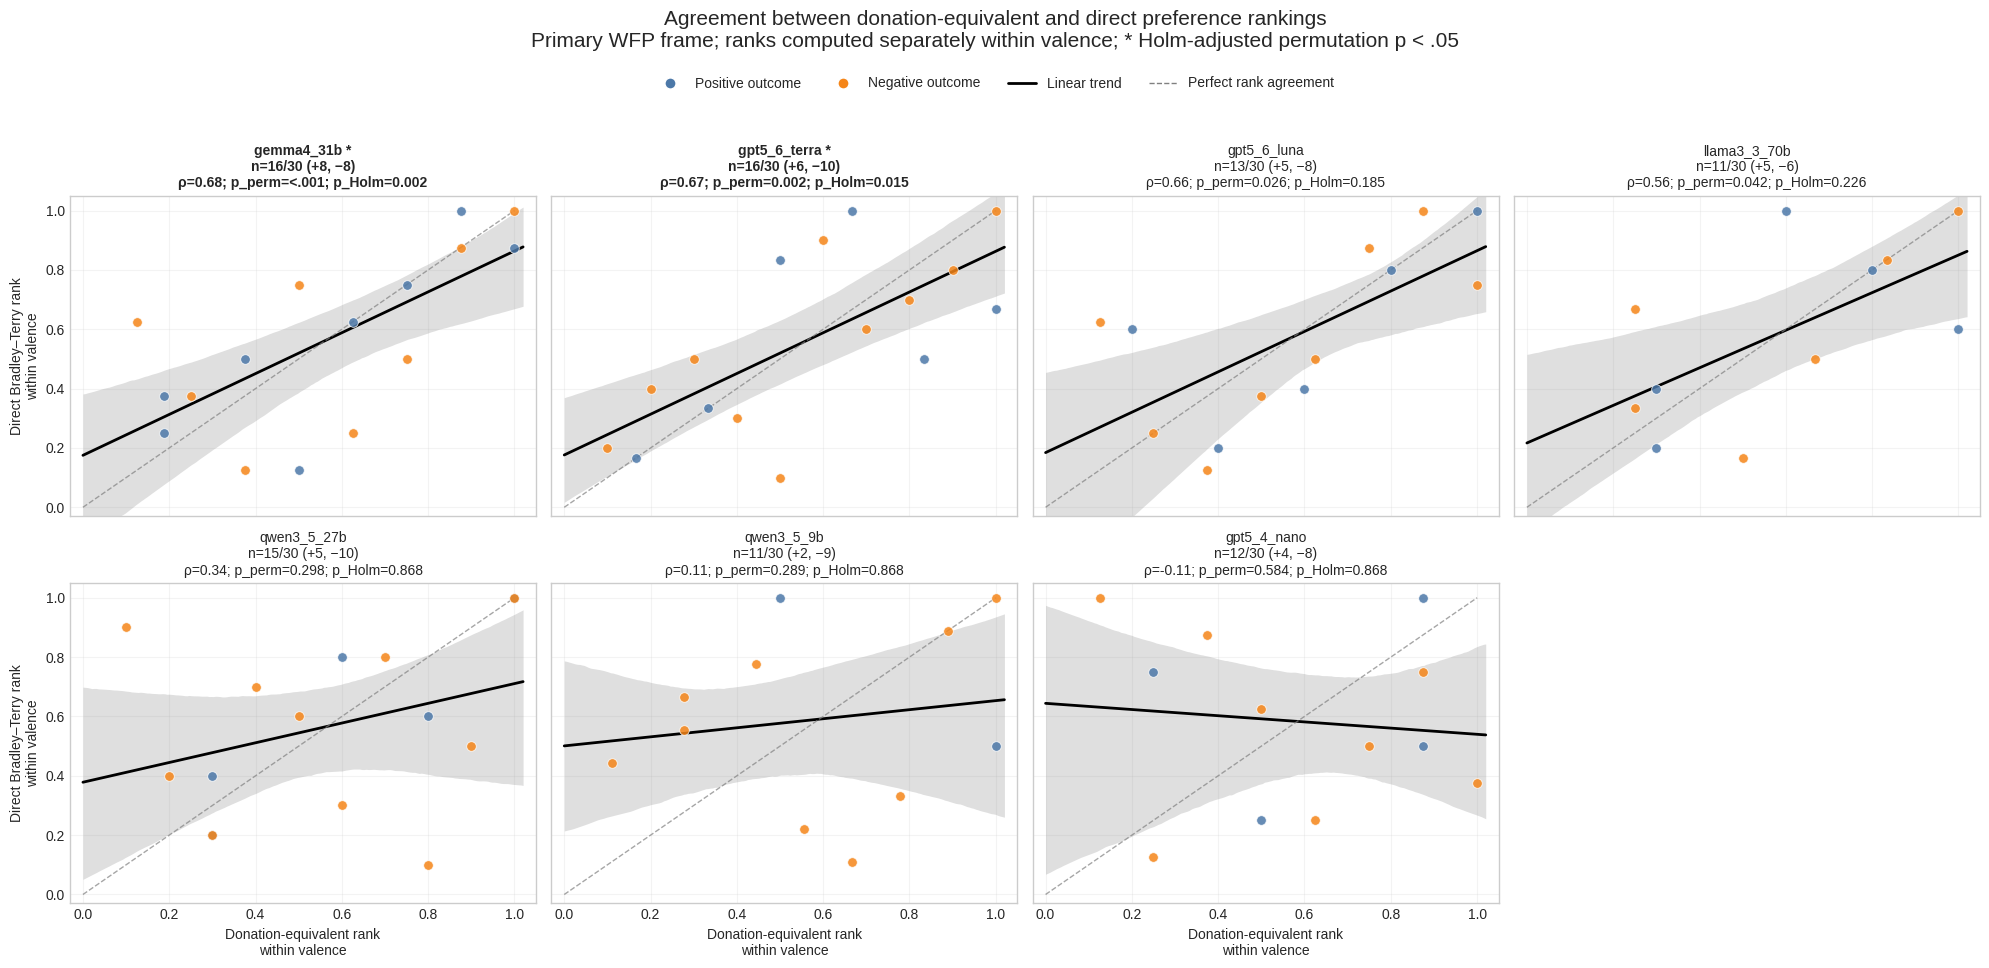

Saved: /content/drive/MyDrive/apart_sprint/mint_tier4_donation_stage1_v7/confirmatory_analysis_v1/figures/cross_instrument_rank_agreement.png


In [15]:
# Cross-instrument rank-agreement figure:
# donation-equivalent ranks versus direct Bradley–Terry ranks.
#
# Ranks are computed separately within positive and negative valence to avoid
# inflating agreement through the trivial positive-versus-negative distinction.

from scipy.stats import spearmanr
from matplotlib.lines import Line2D

RANK_BOOTSTRAPS = 4_000
RANK_PLOT_SEED = RANDOM_SEED + 701

VALENCE_COLORS = {
    "positive": "#4C78A8",
    "negative": "#F58518",
}

VALENCE_LABELS = {
    "positive": "Positive outcome",
    "negative": "Negative outcome",
}


def fit_bradley_terry(pair_group):
    """
    Fit Bradley–Terry scores from repeated direct pairwise choices.

    logit(P(left preferred)) = utility(left) - utility(right)
    """

    usable = pair_group.loc[
        pair_group["n_valid"].gt(0)
    ].copy()

    outcomes = sorted(
        set(usable["left_outcome_id"])
        | set(usable["right_outcome_id"])
    )

    if len(outcomes) < 2:
        return pd.DataFrame(
            columns=["outcome_id", "direct_bt_score"]
        )

    # Set one outcome's score to zero for identifiability.
    reference = outcomes[-1]
    estimated_outcomes = outcomes[:-1]
    outcome_index = {
        outcome: index
        for index, outcome in enumerate(estimated_outcomes)
    }

    X = np.zeros(
        (len(usable), len(estimated_outcomes)),
        dtype=float,
    )

    for row_index, row in enumerate(
        usable.itertuples(index=False)
    ):
        if row.left_outcome_id != reference:
            X[
                row_index,
                outcome_index[row.left_outcome_id],
            ] += 1.0

        if row.right_outcome_id != reference:
            X[
                row_index,
                outcome_index[row.right_outcome_id],
            ] -= 1.0

    y = (
        usable["left_votes"].to_numpy(float)
        / usable["n_valid"].to_numpy(float)
    )
    weights = usable["n_valid"].to_numpy(float)

    model = sm.GLM(
        y,
        X,
        family=sm.families.Binomial(),
        freq_weights=weights,
    )

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fit = model.fit(maxiter=300)

        parameters = np.asarray(fit.params, dtype=float)

    except Exception:
        # Very weak L2 regularization provides a stable descriptive rank
        # if the ordinary fit encounters separation.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fit = model.fit_regularized(
                alpha=1e-6,
                L1_wt=0.0,
                maxiter=500,
            )

        parameters = np.asarray(fit.params, dtype=float)

    scores = {
        outcome: parameters[index]
        for outcome, index in outcome_index.items()
    }
    scores[reference] = 0.0

    return pd.DataFrame({
        "outcome_id": list(scores.keys()),
        "direct_bt_score": list(scores.values()),
    })


def bootstrap_rank_regression(
    points,
    x_grid,
    rng,
    n_bootstraps=RANK_BOOTSTRAPS,
):
    """
    Stratified outcome bootstrap.

    Positive and negative outcomes are resampled separately so the
    bootstrap preserves the observed valence composition.
    """

    bootstrap_lines = []

    for _ in range(n_bootstraps):
        sampled_groups = []

        for _, valence_group in points.groupby("valence"):
            sampled_indices = rng.integers(
                0,
                len(valence_group),
                size=len(valence_group),
            )

            sampled_groups.append(
                valence_group.iloc[sampled_indices]
            )

        sample = pd.concat(
            sampled_groups,
            ignore_index=True,
        )

        x = sample["donation_rank_within_valence"].to_numpy()
        y = sample["direct_rank_within_valence"].to_numpy()

        if np.unique(x).size < 2:
            continue

        slope, intercept = np.polyfit(x, y, deg=1)
        bootstrap_lines.append(
            intercept + slope * x_grid
        )

    if not bootstrap_lines:
        missing = np.full_like(x_grid, np.nan)
        return missing, missing

    bootstrap_lines = np.asarray(bootstrap_lines)

    lower, upper = np.quantile(
        bootstrap_lines,
        [0.025, 0.975],
        axis=0,
    )

    return lower, upper


def format_p_value(value):
    if not np.isfinite(value):
        return "NA"
    if value < 0.001:
        return "<.001"
    return f"{value:.3f}"


# ------------------------------------------------------------------
# 1. Derive direct Bradley–Terry scores
# ------------------------------------------------------------------

quality_models = set(
    model_quality.loc[
        model_quality["quality_eligible"],
        "model_label",
    ]
)

direct_for_bt = pair_summary.loc[
    pair_summary["model_label"].isin(quality_models)
    & pair_summary["temperature"].eq(
        VALIDATION_TEMPERATURE
    )
].copy()

bt_score_frames = []

for model_label, group in direct_for_bt.groupby(
    "model_label",
    sort=True,
):
    model_scores = fit_bradley_terry(group)
    model_scores["model_label"] = model_label
    bt_score_frames.append(model_scores)

bt_scores = pd.concat(
    bt_score_frames,
    ignore_index=True,
)


# ------------------------------------------------------------------
# 2. Join finite donation equivalents from the primary WFP frame
# ------------------------------------------------------------------

finite_donation_scores = trend_results.loc[
    trend_results["model_label"].isin(quality_models)
    & trend_results["charity_frame"].eq(PRIMARY_FRAME)
    & trend_results["d50_status"].eq(
        "identified_within_grid"
    ),
    [
        "model_label",
        "outcome_id",
        "valence",
        "signed_d50_usd",
        "d50_usd",
    ],
].copy()

rank_points = finite_donation_scores.merge(
    bt_scores,
    on=["model_label", "outcome_id"],
    how="inner",
)

# Compute ranks independently within each model and valence.
# Percentile ranks allow positive and negative subsets of different sizes
# to appear on the same axes.
rank_points["donation_rank_within_valence"] = (
    rank_points.groupby(
        ["model_label", "valence"]
    )["signed_d50_usd"]
    .rank(
        method="average",
        pct=True,
    )
)

rank_points["direct_rank_within_valence"] = (
    rank_points.groupby(
        ["model_label", "valence"]
    )["direct_bt_score"]
    .rank(
        method="average",
        pct=True,
    )
)


# ------------------------------------------------------------------
# 3. Calculate descriptive correlations and attach permutation tests
# ------------------------------------------------------------------

rank_summary_rows = []

for model_label, group in rank_points.groupby(
    "model_label",
    sort=True,
):
    n_positive = int(group["valence"].eq("positive").sum())
    n_negative = int(group["valence"].eq("negative").sum())

    if len(group) >= 3:
        rho = float(
            spearmanr(
                group["donation_rank_within_valence"],
                group["direct_rank_within_valence"],
            ).statistic
        )
    else:
        rho = np.nan

    prediction_row = prediction_summary.loc[
        prediction_summary["model_label"].eq(model_label)
    ]

    if len(prediction_row):
        prediction_row = prediction_row.iloc[0]

        permutation_p = prediction_row.get(
            "permutation_p",
            np.nan,
        )
        holm_p = prediction_row.get(
            "permutation_p_holm_all_models",
            np.nan,
        )
        significant = bool(
            prediction_row.get(
                "significant_conservative",
                False,
            )
        )
        prediction_accuracy = prediction_row.get(
            "within_accuracy",
            np.nan,
        )
    else:
        permutation_p = np.nan
        holm_p = np.nan
        significant = False
        prediction_accuracy = np.nan

    rank_summary_rows.append({
        "model_label": model_label,
        "finite_outcomes": len(group),
        "positive_outcomes": n_positive,
        "negative_outcomes": n_negative,
        "within_valence_spearman_rho": rho,
        "within_valence_prediction_accuracy": prediction_accuracy,
        "task_label_permutation_p": permutation_p,
        "holm_p_across_models": holm_p,
        "significant_after_holm": significant,
    })

rank_agreement_summary = pd.DataFrame(
    rank_summary_rows
)

# Significant endpoints first, then order descriptively by rho.
rank_agreement_summary = rank_agreement_summary.sort_values(
    [
        "significant_after_holm",
        "within_valence_spearman_rho",
    ],
    ascending=[False, False],
).reset_index(drop=True)

display(rank_agreement_summary.round(4))


# ------------------------------------------------------------------
# 4. Produce the paper-style multipanel figure
# ------------------------------------------------------------------

plot_models = rank_agreement_summary.loc[
    rank_agreement_summary["finite_outcomes"].ge(4),
    "model_label",
].tolist()

if not plot_models:
    raise RuntimeError(
        "No quality-eligible model has at least four finite "
        "donation-equivalent outcomes."
    )

n_columns = min(4, len(plot_models))
n_rows = math.ceil(len(plot_models) / n_columns)

figure, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(5.0 * n_columns, 4.5 * n_rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes_flat = axes.ravel()
x_grid = np.linspace(0.0, 1.02, 200)
bootstrap_rng = np.random.default_rng(RANK_PLOT_SEED)

for axis_index, model_label in enumerate(plot_models):
    axis = axes_flat[axis_index]

    points = rank_points.loc[
        rank_points["model_label"].eq(model_label)
    ].copy()

    summary_row = rank_agreement_summary.loc[
        rank_agreement_summary["model_label"].eq(
            model_label
        )
    ].iloc[0]

    # Scatter outcomes by valence.
    for valence in ["positive", "negative"]:
        valence_points = points.loc[
            points["valence"].eq(valence)
        ]

        axis.scatter(
            valence_points[
                "donation_rank_within_valence"
            ],
            valence_points[
                "direct_rank_within_valence"
            ],
            s=48,
            color=VALENCE_COLORS[valence],
            edgecolor="white",
            linewidth=0.6,
            alpha=0.85,
            zorder=3,
        )

    # Descriptive linear trend.
    x = points[
        "donation_rank_within_valence"
    ].to_numpy(float)
    y = points[
        "direct_rank_within_valence"
    ].to_numpy(float)

    if np.unique(x).size >= 2:
        slope, intercept = np.polyfit(x, y, deg=1)
        fitted_line = intercept + slope * x_grid

        lower, upper = bootstrap_rank_regression(
            points,
            x_grid,
            bootstrap_rng,
        )

        axis.fill_between(
            x_grid,
            lower,
            upper,
            color="gray",
            alpha=0.25,
            linewidth=0,
            label="Outcome-bootstrap 95% interval",
        )

        axis.plot(
            x_grid,
            fitted_line,
            color="black",
            linewidth=2,
            label="Linear trend",
        )

    # Perfect rank agreement reference.
    axis.plot(
        [0, 1],
        [0, 1],
        color="gray",
        linestyle="--",
        linewidth=1,
        alpha=0.7,
    )

    significance_marker = (
        " *" if summary_row.significant_after_holm else ""
    )

    axis.set_title(
        f"{model_label}{significance_marker}\n"
        f"n={int(summary_row.finite_outcomes)}/30 "
        f"(+{int(summary_row.positive_outcomes)}, "
        f"−{int(summary_row.negative_outcomes)})\n"
        f"ρ={summary_row.within_valence_spearman_rho:.2f}; "
        f"p_perm={format_p_value(summary_row.task_label_permutation_p)}; "
        f"p_Holm={format_p_value(summary_row.holm_p_across_models)}",
        fontsize=10,
        fontweight=(
            "bold"
            if summary_row.significant_after_holm
            else "normal"
        ),
    )

    axis.set_xlim(-0.03, 1.05)
    axis.set_ylim(-0.03, 1.05)
    axis.grid(alpha=0.22)

    row_index = axis_index // n_columns
    column_index = axis_index % n_columns

    if row_index == n_rows - 1:
        axis.set_xlabel(
            "Donation-equivalent rank\nwithin valence"
        )

    if column_index == 0:
        axis.set_ylabel(
            "Direct Bradley–Terry rank\nwithin valence"
        )

# Hide unused panels.
for axis in axes_flat[len(plot_models):]:
    axis.set_visible(False)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=VALENCE_COLORS["positive"],
        markeredgecolor="white",
        markersize=8,
        label="Positive outcome",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=VALENCE_COLORS["negative"],
        markeredgecolor="white",
        markersize=8,
        label="Negative outcome",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=2,
        label="Linear trend",
    ),
    Line2D(
        [0],
        [0],
        color="gray",
        linestyle="--",
        linewidth=1,
        label="Perfect rank agreement",
    ),
]

figure.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=4,
    frameon=False,
)

figure.suptitle(
    "Agreement between donation-equivalent and direct preference rankings\n"
    "Primary WFP frame; ranks computed separately within valence; "
    "* Holm-adjusted permutation p < .05",
    y=1.07,
    fontsize=15,
)

figure.tight_layout()

rank_figure_path = (
    FIGURE_DIR / "cross_instrument_rank_agreement.png"
)

figure.savefig(
    rank_figure_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()

rank_points.to_csv(
    TABLE_DIR / "cross_instrument_rank_points.csv",
    index=False,
)

rank_agreement_summary.to_csv(
    TABLE_DIR / "cross_instrument_rank_summary.csv",
    index=False,
)

print("Saved:", rank_figure_path)

## 7. Report-ready summary table and saved outputs



In [12]:
cycle_overall = cycle_summary.loc[
    cycle_summary["triad_scope"].eq("all"),
    [
        "model_label",
        "observed_cycle_rate",
        "guaranteed_cycle_lower_bound",
        "robust_subgraph_cycle_rate",
    ],
]

report_table = (
    model_quality.merge(
        quality.loc[quality["phase"].eq("direct_tier4"), [
            "model_label",
            "api_success_rate",
            "parse_yield",
            "conditional_parse_rate",
            "length_finish_rate",
        ]],
        on="model_label",
        how="left",
    )
    .merge(pair_quality_summary, on="model_label", how="left")
    .merge(cycle_overall, on="model_label", how="left")
    .merge(
        monotonicity_summary[[
            "model_label",
            "strict_monotonicity_rate",
            "significant_trend_rate",
            "finite_d50_outcomes",
            "below_grid_outcomes",
            "above_grid_outcomes",
        ]],
        on="model_label",
        how="left",
    )
    .merge(
        prediction_summary[[
            "model_label",
            "n_within_pairs",
            "within_accuracy",
            "permutation_p_holm_all_models",
            "significant_conservative",
        ]],
        on="model_label",
        how="left",
    )
)

report_columns = [
    "model_label",
    "quality_eligible",
    "api_success_rate",
    "parse_yield",
    "conditional_parse_rate",
    "length_finish_rate",
    "mean_valid_per_pair",
    "observed_cycle_rate",
    "guaranteed_cycle_lower_bound",
    "strict_monotonicity_rate",
    "significant_trend_rate",
    "finite_d50_outcomes",
    "below_grid_outcomes",
    "above_grid_outcomes",
    "n_within_pairs",
    "within_accuracy",
    "permutation_p_holm_all_models",
    "significant_conservative",
]
report_table = report_table[report_columns].sort_values(
    ["significant_conservative", "within_accuracy"], ascending=[False, False]
)
display(report_table.reset_index(drop=True).round(4))

report_table_path = TABLE_DIR / "report_ready_model_summary.csv"
report_table.to_csv(report_table_path, index=False)

try:
    markdown_table = report_table.round(4).to_markdown(index=False)
except Exception:
    markdown_table = "```csv\n" + report_table.round(4).to_csv(index=False) + "```"

significant_text = []
for row in prediction_summary.loc[prediction_summary["significant_conservative"]].itertuples(index=False):
    significant_text.append(
        f"- **{row.model_label}:** {row.within_accuracy:.1%} within-valence accuracy "
        f"over {row.n_within_pairs} pairs; Holm-adjusted p={row.permutation_p_holm_all_models:.4f}."
    )
if not significant_text:
    significant_text = ["- No quality-eligible endpoint survived conservative correction."]

results_markdown = f"""# Report-ready Stage 1 analysis

## Primary cross-instrument findings

{chr(10).join(significant_text)}

The correction family contains all ten endpoints. Endpoints failing the uniform
post-hoc API/conditional-parse/truncation rule remain in the table but are not
interpreted as primary evidence.

## Important model-level information

{markdown_table}

## Figures

1. `figures/cycle_missingness_sensitivity.png` — observed cycles and cycles guaranteed
   despite adversarial assignment of every missing response.
2. `figures/monotonicity_rates_quality_eligible.png` — strict monotonicity and
   BH-significant negative donation trends with Wilson intervals.
3. `figures/within_valence_prediction_significance.png` — cross-instrument accuracy
   against the task-label permutation null.
4. `figures/significant_models_monotonicity_curves.png` — paper-style mean donation
   curves with outcome-bootstrap 95% intervals for significant endpoints.

## Interpretation boundary

These statistics describe sampled endpoint choices under the recorded prompts. They do
not establish consciousness, experienced welfare, or persistent internal preferences.
Donation crossings are conditional on the charity frame and the tested monetary range.
"""

results_markdown_path = ANALYSIS_DIR / "report_ready_results.md"
results_markdown_path.write_text(results_markdown, encoding="utf-8")

manifest = {
    "source_responses": str(RESPONSES_CSV),
    "analysis_directory": str(ANALYSIS_DIR),
    "primary_frame": PRIMARY_FRAME,
    "validation_temperature_metadata": VALIDATION_TEMPERATURE,
    "quality_rule": {
        "api_min": QUALITY_API_MIN,
        "conditional_parse_min": QUALITY_CONDITIONAL_PARSE_MIN,
        "length_max": QUALITY_LENGTH_MAX,
        "status": "post_hoc_sensitivity_rule",
    },
    "n_permutations": N_PERMUTATIONS,
    "n_bootstraps": N_BOOTSTRAPS,
    "random_seed": RANDOM_SEED,
    "files": [str(path) for path in sorted(ANALYSIS_DIR.rglob("*")) if path.is_file()],
}
(ANALYSIS_DIR / "analysis_manifest.json").write_text(
    json.dumps(manifest, indent=2), encoding="utf-8"
)

print("\nSaved report-ready analysis:")
for path in sorted(ANALYSIS_DIR.rglob("*")):
    if path.is_file():
        print(" -", path)

display(Markdown(results_markdown))


,model_label,quality_eligible,api_success_rate,parse_yield,conditional_parse_rate,length_finish_rate,mean_valid_per_pair,observed_cycle_rate,guaranteed_cycle_lower_bound,strict_monotonicity_rate,significant_trend_rate,finite_d50_outcomes,below_grid_outcomes,above_grid_outcomes,n_within_pairs,within_accuracy,permutation_p_holm_all_models,significant_conservative
0,gemma4_31b,True,1.0000,0.9759,0.9759,0.0094,19.5172,0.0035,0.0027,0.7333,0.3333,16,7,7,52,0.8558,0.0025,True
1,gpt5_6_terra,True,0.9998,0.9998,1.0000,0.0000,19.9954,0.0025,0.0025,0.4667,0.7667,16,10,4,58,0.7931,0.0153,True
2,llama3_2_3b,False,0.9633,0.7415,0.7697,0.0425,14.8299,0.0155,0.0000,0.0000,0.0333,9,19,2,14,0.7857,0.2312,False
3,gpt5_6_luna,True,0.9999,0.9999,1.0000,0.0000,19.9977,0.0026,0.0026,0.4333,0.7333,13,8,9,36,0.7500,0.1855,False
4,llama3_3_70b,True,0.9724,0.9724,1.0000,0.0000,19.4483,0.0044,0.0006,0.6667,0.3667,11,9,10,24,0.7500,0.2256,False
5,llama3_2_1b,False,0.9999,0.1736,0.1736,0.0000,3.4713,0.2309,0.0000,0.0000,0.0667,13,5,12,28,0.7321,0.0652,False
6,gemma4_26b_a4b,False,0.8205,0.7691,0.9374,0.0027,15.3816,0.0115,0.0000,0.5667,0.4000,15,11,4,46,0.6957,0.2256,False
7,qwen3_5_9b,True,0.9980,0.9945,0.9964,0.0007,19.8897,0.0088,0.0079,0.0000,0.4667,11,16,3,35,0.5714,0.8683,False
8,qwen3_5_27b,True,0.9932,0.9932,1.0000,0.0000,19.8644,0.0064,0.0046,0.1333,0.9000,15,10,5,54,0.5648,0.8683,False
9,gpt5_4_nano,True,1.0000,1.0000,1.0000,0.0000,20.0000,0.0074,0.0074,0.1333,0.5333,12,17,1,30,0.4833,0.8683,False



Saved report-ready analysis:
 - /content/drive/MyDrive/apart_sprint/mint_tier4_donation_stage1_v7/confirmatory_analysis_v1/analysis_manifest.json
 - /content/drive/MyDrive/apart_sprint/mint_tier4_donation_stage1_v7/confirmatory_analysis_v1/figures/cycle_missingness_sensitivity.png
 - /content/drive/MyDrive/apart_sprint/mint_tier4_donation_stage1_v7/confirmatory_analysis_v1/figures/monotonicity_rates_quality_eligible.png
 - /content/drive/MyDrive/apart_sprint/mint_tier4_donation_stage1_v7/confirmatory_analysis_v1/figures/significant_models_monotonicity_curves.png
 - /content/drive/MyDrive/apart_sprint/mint_tier4_donation_stage1_v7/confirmatory_analysis_v1/figures/within_valence_prediction_significance.png
 - /content/drive/MyDrive/apart_sprint/mint_tier4_donation_stage1_v7/confirmatory_analysis_v1/report_ready_results.md
 - /content/drive/MyDrive/apart_sprint/mint_tier4_donation_stage1_v7/confirmatory_analysis_v1/tables/cycle_sensitivity_by_valence.csv
 - /content/drive/MyDrive/apart_s

# Report-ready Stage 1 analysis

## Primary cross-instrument findings

- **gemma4_31b:** 85.6% within-valence accuracy over 52 pairs; Holm-adjusted p=0.0025.
- **gpt5_6_terra:** 79.3% within-valence accuracy over 58 pairs; Holm-adjusted p=0.0153.

The correction family contains all ten endpoints. Endpoints failing the uniform
post-hoc API/conditional-parse/truncation rule remain in the table but are not
interpreted as primary evidence.

## Important model-level information

| model_label    | quality_eligible   |   api_success_rate |   parse_yield |   conditional_parse_rate |   length_finish_rate |   mean_valid_per_pair |   observed_cycle_rate |   guaranteed_cycle_lower_bound |   strict_monotonicity_rate |   significant_trend_rate |   finite_d50_outcomes |   below_grid_outcomes |   above_grid_outcomes |   n_within_pairs |   within_accuracy |   permutation_p_holm_all_models | significant_conservative   |
|:---------------|:-------------------|-------------------:|--------------:|-------------------------:|---------------------:|----------------------:|----------------------:|-------------------------------:|---------------------------:|-------------------------:|----------------------:|----------------------:|----------------------:|-----------------:|------------------:|--------------------------------:|:---------------------------|
| gemma4_31b     | True               |             1      |        0.9759 |                   0.9759 |               0.0094 |               19.5172 |                0.0035 |                         0.0027 |                     0.7333 |                   0.3333 |                    16 |                     7 |                     7 |               52 |            0.8558 |                          0.0025 | True                       |
| gpt5_6_terra   | True               |             0.9998 |        0.9998 |                   1      |               0      |               19.9954 |                0.0025 |                         0.0025 |                     0.4667 |                   0.7667 |                    16 |                    10 |                     4 |               58 |            0.7931 |                          0.0153 | True                       |
| llama3_2_3b    | False              |             0.9633 |        0.7415 |                   0.7697 |               0.0425 |               14.8299 |                0.0155 |                         0      |                     0      |                   0.0333 |                     9 |                    19 |                     2 |               14 |            0.7857 |                          0.2312 | False                      |
| gpt5_6_luna    | True               |             0.9999 |        0.9999 |                   1      |               0      |               19.9977 |                0.0026 |                         0.0026 |                     0.4333 |                   0.7333 |                    13 |                     8 |                     9 |               36 |            0.75   |                          0.1855 | False                      |
| llama3_3_70b   | True               |             0.9724 |        0.9724 |                   1      |               0      |               19.4483 |                0.0044 |                         0.0006 |                     0.6667 |                   0.3667 |                    11 |                     9 |                    10 |               24 |            0.75   |                          0.2256 | False                      |
| llama3_2_1b    | False              |             0.9999 |        0.1736 |                   0.1736 |               0      |                3.4713 |                0.2309 |                         0      |                     0      |                   0.0667 |                    13 |                     5 |                    12 |               28 |            0.7321 |                          0.0652 | False                      |
| gemma4_26b_a4b | False              |             0.8205 |        0.7691 |                   0.9374 |               0.0027 |               15.3816 |                0.0115 |                         0      |                     0.5667 |                   0.4    |                    15 |                    11 |                     4 |               46 |            0.6957 |                          0.2256 | False                      |
| qwen3_5_9b     | True               |             0.998  |        0.9945 |                   0.9964 |               0.0007 |               19.8897 |                0.0088 |                         0.0079 |                     0      |                   0.4667 |                    11 |                    16 |                     3 |               35 |            0.5714 |                          0.8683 | False                      |
| qwen3_5_27b    | True               |             0.9932 |        0.9932 |                   1      |               0      |               19.8644 |                0.0064 |                         0.0046 |                     0.1333 |                   0.9    |                    15 |                    10 |                     5 |               54 |            0.5648 |                          0.8683 | False                      |
| gpt5_4_nano    | True               |             1      |        1      |                   1      |               0      |               20      |                0.0074 |                         0.0074 |                     0.1333 |                   0.5333 |                    12 |                    17 |                     1 |               30 |            0.4833 |                          0.8683 | False                      |

## Figures

1. `figures/cycle_missingness_sensitivity.png` — observed cycles and cycles guaranteed
   despite adversarial assignment of every missing response.
2. `figures/monotonicity_rates_quality_eligible.png` — strict monotonicity and
   BH-significant negative donation trends with Wilson intervals.
3. `figures/within_valence_prediction_significance.png` — cross-instrument accuracy
   against the task-label permutation null.
4. `figures/significant_models_monotonicity_curves.png` — paper-style mean donation
   curves with outcome-bootstrap 95% intervals for significant endpoints.

## Interpretation boundary

These statistics describe sampled endpoint choices under the recorded prompts. They do
not establish consciousness, experienced welfare, or persistent internal preferences.
Donation crossings are conditional on the charity frame and the tested monetary range.
